# **Regression and Prediction**

In [2031]:
from pathlib import Path

import pandas as pd
import numpy as np
from sklearn.metrics import r2_score, mean_squared_error
from sklearn.linear_model import LinearRegression

import statsmodels.api as sm
import statsmodels.formula.api as smf
from statsmodels.stats.outliers_influence import OLSInfluence

# from pygam import LinearGAM, s, l
# from pygam.datasets import wage


import seaborn as sns
import matplotlib.pyplot as plt

from dmba import stepwise_selection
from dmba import AIC_score

%matplotlib inline

In [2032]:
data_dir = Path("Data4")
LUNG_CSV = data_dir / 'LungDisease.csv'
HOUSE_CSV = data_dir / 'house_sales.csv'

## **Simple Linear Regression**  
- **The Regression Equation**

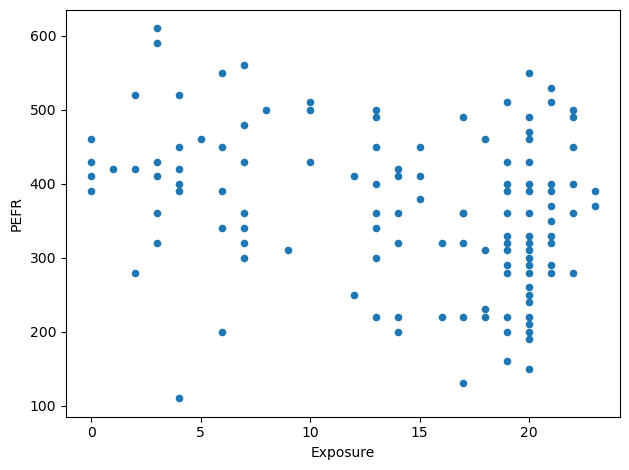

In [2033]:
lung = pd.read_csv(LUNG_CSV) # It's a DataFrame with columns 'Exposure' and 'PEFR'.

lung.plot.scatter(x='Exposure', y='PEFR') # It’s pandas’ built-in plotting via the .plot accessor, which wraps Matplotlib under the hood. This returns a Matplotlib Axes object.

plt.tight_layout()
plt.show()

In [2034]:
lung.head()

,PEFR,Exposure
0,390,0
1,410,0
2,430,0
3,460,0
4,420,1


In [2035]:
lung.shape

(122, 2)

In [2036]:
lung.columns

Index(['PEFR', 'Exposure'], dtype='object')

In [2037]:
lung.index

RangeIndex(start=0, stop=122, step=1)

In [2038]:
lung['Exposure'].shape

(122,)

In [2039]:
lung[['Exposure']].shape

(122, 1)

In [2040]:
predictors = ['Exposure'] # If the 'predictors' list has one element, it's simple linear regression; if it has more than one, it's multiple linear regression.
outcome = 'PEFR'

model = LinearRegression()
model.fit(lung[predictors], lung[outcome])
'''
model.fit(X, y)
X must be 2-D: shape (n_samples, n_features).
y (the target) for single-output problems is typically 1-D: shape (n_samples,) — e.g. a pandas Series like lung['PEFR'].
'''

print(f'Intercept: {model.intercept_:.3f}')
print(f'Coefficient Exposure: {model.coef_[0]:.3f}')

Intercept: 424.583
Coefficient Exposure: -4.185


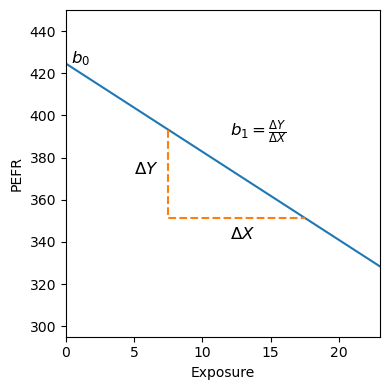

In [2041]:
fig, ax = plt.subplots(1,1, figsize=(4, 4))
ax.set_xlim(0, 23)
ax.set_ylim(295, 450)
ax.set_xlabel('Exposure')
ax.set_ylabel('PEFR')
ax.plot((0, 23), model.predict(pd.DataFrame({'Exposure': [0, 23]})))
'''
Draw the regression line by predicting just two endpoints and letting Matplotlib connect them:
X values: 0 and 23
Y values: predictions at those two X’s (must pass a DataFrame with column name matching your model fit).
'''
ax.text(0.4, model.intercept_, r'$b_0$', size='larger')

x = pd.DataFrame({'Exposure': [7.5,17.5]})
y = model.predict(x) # (2,)
ax.plot((7.5, 7.5, 17.5), (y[0], y[1], y[1]), '--')
ax.text(5, np.mean(y), r'$\Delta Y$', size='larger')
ax.text(12, y[1] - 10, r'$\Delta X$', size='larger')
ax.text(12, 390, r'$b_1 = \frac{\Delta Y}{\Delta X}$', size='larger')

plt.tight_layout()
plt.show();

In [2042]:
pd.DataFrame({'Exposure': [0, 23]}) #Scikit-learn expects X to be 2D so we passed a DataFrame (2-D) to LinearRegression.predict (Just like what we did to LinearRegression.fit)

,Exposure
0,0
1,23


In [2043]:
Y_hat = model.predict(pd.DataFrame({'Exposure': [0, 23]}))
Y_hat.shape #(2,)
Y_hat

array([424.58280657, 328.33754741])

In [2044]:
x = pd.DataFrame({'Exposure': [7.5,17.5]})
y = model.predict(x)
y.shape
y[0]

np.float64(393.19848293299617)

## **Fitted Values and Residuals**  
- **The method `predict` of a *fitted* scikit-learn model can be used to predict new data points.**

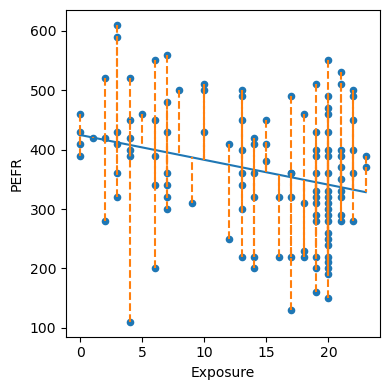

In [2045]:
fitted = model.predict(lung[predictors])
residuals = lung[outcome] - fitted
ax = lung.plot.scatter(x='Exposure', y='PEFR', figsize=(4, 4))
ax.plot(lung['Exposure'], fitted, '-')
for x, yactual, yfitted in zip(lung['Exposure'], lung['PEFR'], fitted): 
    ax.plot((x, x), (yactual, yfitted), '--', color='C1')

plt.tight_layout()
plt.show()

## **Multiple linear regression**

In [2046]:
subset = ['AdjSalePrice', 'SqFtTotLiving', 'SqFtLot', 'Bathrooms', 
          'Bedrooms', 'BldgGrade']

house = pd.read_csv(HOUSE_CSV, sep='\t') # sep='\t' tells pandas the columns are separated by tabs (TSV format), not commas.
print(house[subset].head())

   AdjSalePrice  SqFtTotLiving  SqFtLot  Bathrooms  Bedrooms  BldgGrade
1      300805.0           2400     9373       3.00         6          7
2     1076162.0           3764    20156       3.75         4         10
3      761805.0           2060    26036       1.75         4          8
4      442065.0           3200     8618       3.75         5          7
5      297065.0           1720     8620       1.75         4          7


In [2047]:
house[subset].info()

<class 'pandas.core.frame.DataFrame'>
Index: 22687 entries, 1 to 27063
Data columns (total 6 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   AdjSalePrice   22687 non-null  float64
 1   SqFtTotLiving  22687 non-null  int64  
 2   SqFtLot        22687 non-null  int64  
 3   Bathrooms      22687 non-null  float64
 4   Bedrooms       22687 non-null  int64  
 5   BldgGrade      22687 non-null  int64  
dtypes: float64(2), int64(4)
memory usage: 1.2 MB


In [2048]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 
              'Bedrooms', 'BldgGrade']
outcome = 'AdjSalePrice'

house_lm = LinearRegression()
house_lm.fit(house[predictors], house[outcome]) # (house[predictors]: 2D DataFrame     house[outcome : 1D Series)

print(f'Intercept: {house_lm.intercept_:.3f}')
print('Coefficients:')
for name, coef in zip(predictors, house_lm.coef_):
    print(f' {name}: {coef}')

Intercept: -521871.368
Coefficients:
 SqFtTotLiving: 228.83060360240515
 SqFtLot: -0.06046682065306008
 Bathrooms: -19442.840398321394
 Bedrooms: -47769.95518521384
 BldgGrade: 106106.9630789812


## **Assessing the Model**  

Scikit-learn provides a number of metrics to determine the quality of a model. Here we use the `RMSE` and `r2_score`.

In [2049]:
fitted = house_lm.predict(house[predictors])
RMSE = np.sqrt(mean_squared_error(house[outcome], fitted)) # RMSE: 261220
r2 = r2_score(house[outcome], fitted) # r2: 0.5406
print(f'RMSE: {RMSE:.0f}')
print(f'r2: {r2:.4f}')

RMSE: 261220
r2: 0.5406


- **RMSE ≈ 261,220** → Our model’s average error (in price units) is about $261k. Whether that’s “good” depends on the typical sale price spread; by itself, 261k is large unless prices are in the multi-million range.

- **$R^2 ≈ 0.5406$** → the model explains about 54% of the variance in sale prices (on the data you predicted on).

**A few important caveats & checks:**  

- **We evaluated in-sample.**  
  `house_lm.predict(house[predictors])` uses the same data that fit the model → performance is optimistic. We should  do a train/test split or cross-validation.

- **Judge RMSE relative to scale.**  
  Compute median/mean price and compare:


In [2050]:
y = house[outcome]
y.mean(), y.median(), y.std()

(np.float64(565233.2705514171), 471315.0, 385402.8600477193)

These summary stats give us context:

- **Mean price** ≈ $565k, **median** ≈ $471k, **std** ≈ $385k → prices are right-skewed (mean > median), which is typical for housing.
- Our **RMSE** ≈ $261k is:
  - ~46% of the mean (261k / 565k)
  - ~55% of the median (261k / 471k)

**Baseline comparison**:  
Predicting a constant (≈ the mean) would yield RMSE ≈ the std ≈ $385k.  
Our model’s RMSE drops from ~385k to ~261k:
- ~32% lower RMSE, or
- ~54% lower MSE, which matches $R^2 \approx 0.5406 \; (= 1 - (261/385)^2)$.

**Is it “good”?**  

- **Statistically**: moderate. We’re explaining ~54% of price variance on the (training) data.
- **Practically**: For pricing, an average error of $261k is large unless homes are multi-million. I’d call this not accurate enough for valuation decisions yet.


While *scikit-learn* provides a variety of different metrics, *statsmodels* provides a more in-depth analysis of the linear regression model. This package has two different ways of specifying the model, one that is similar to scikit-learn and one that allows specifying R-style formulas. Here we use the first approach. As *statsmodels* doesn't add an intercept automaticaly, we need to add a constant column with value 1 to the predictors. We can use the *pandas* method assign for this.

In [2051]:
# model = sm.OLS(house[outcome], house[predictors].assign(const=1))
'''
model = sm.OLS(house[outcome], house[predictors].assign(const=1))
sm.OLS(y, X) is statsmodels’ Ordinary Least Squares constructor.
house[outcome] is our response/target vector y.
house[predictors] selects our feature matrix X.
.assign(const=1) adds a column named const filled with 1s → this gives the model an intercept. (Statsmodels does not add an intercept automatically in the array API.)
'''
X = house[predictors].assign(const=1)   # add intercept
y = house[outcome]

model = sm.OLS(y, X)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.541
Model:                            OLS   Adj. R-squared:                  0.540
Method:                 Least Squares   F-statistic:                     5338.
Date:                Mon, 15 Sep 2025   Prob (F-statistic):               0.00
Time:                        03:21:45   Log-Likelihood:            -3.1517e+05
No. Observations:               22687   AIC:                         6.304e+05
Df Residuals:                   22681   BIC:                         6.304e+05
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
SqFtTotLiving   228.8306      3.899     58.694

In [2052]:
from scipy.stats import f

n  = 22687
k  = 5
R2 = 0.541  # your in-sample R^2

F = (R2 / k) / ((1 - R2) / (n - k - 1))  # ≈ 5338
df1, df2 = k, n - k - 1

p = f.sf(F, df1, df2)        # right-tail prob: Prob(F_{df1,df2} >= F)
logp = f.logsf(F, df1, df2)  # use this to avoid underflow; p = exp(logp)
'''
Use f.sf(...) (survival function) rather than 1 - f.cdf(...) for numerical stability; 
with such a huge F, p will be ~0 to machine precision, while logsf gives a finite log-p.


f in from scipy.stats import f is the Fisher–Snedecor F-distribution object from SciPy’s stats module.
It’s a distribution API with methods like:
f.pdf(x, dfn, dfd) – density
f.cdf(x, dfn, dfd) – CDF (left-tail)
f.sf(x, dfn, dfd) – survival function = 1 - cdf (right-tail; use for p-values)
f.ppf(q, dfn, dfd) / f.isf(q, dfn, dfd) – quantiles  (ppf = percent point function, it is the inverse of the cumulative distribution function.)

f.rvs(dfn, dfd, size=...) – random samples
Here dfn = numerator degrees of freedom =k, dfd = denominator df =n−k−1
'''
print(F, df1, df2, p, logp)

5346.588671023966 5 22681 0.0 -inf


## **Model Selection and Stepwise Regression**

In [2053]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms',
              'BldgGrade', 'PropertyType', 'NbrLivingUnits',
              'SqFtFinBasement', 'YrBuilt', 'YrRenovated', 
              'NewConstruction']
print(house[predictors].head())

   SqFtTotLiving  SqFtLot  Bathrooms  Bedrooms  BldgGrade   PropertyType  \
1           2400     9373       3.00         6          7      Multiplex   
2           3764    20156       3.75         4         10  Single Family   
3           2060    26036       1.75         4          8  Single Family   
4           3200     8618       3.75         5          7  Single Family   
5           1720     8620       1.75         4          7  Single Family   

   NbrLivingUnits  SqFtFinBasement  YrBuilt  YrRenovated  NewConstruction  
1               2                0     1991            0            False  
2               1             1452     2005            0             True  
3               1              900     1947            0            False  
4               1             1640     1966            0            False  
5               1                0     1948            0            False  


In [2054]:
house[predictors].info()

<class 'pandas.core.frame.DataFrame'>
Index: 22687 entries, 1 to 27063
Data columns (total 11 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   SqFtTotLiving    22687 non-null  int64  
 1   SqFtLot          22687 non-null  int64  
 2   Bathrooms        22687 non-null  float64
 3   Bedrooms         22687 non-null  int64  
 4   BldgGrade        22687 non-null  int64  
 5   PropertyType     22687 non-null  object 
 6   NbrLivingUnits   22687 non-null  int64  
 7   SqFtFinBasement  22687 non-null  int64  
 8   YrBuilt          22687 non-null  int64  
 9   YrRenovated      22687 non-null  int64  
 10  NewConstruction  22687 non-null  bool   
dtypes: bool(1), float64(1), int64(8), object(1)
memory usage: 1.9+ MB


In [2055]:
house['PropertyType'].unique()

array(['Multiplex', 'Single Family', 'Townhouse'], dtype=object)

In [2056]:
pd.get_dummies(house[predictors], drop_first=True, dtype=int)

,SqFtTotLiving,SqFtLot,Bathrooms,Bedrooms,BldgGrade,NbrLivingUnits,SqFtFinBasement,YrBuilt,YrRenovated,NewConstruction,PropertyType_Single Family,PropertyType_Townhouse
1,2400,9373,3.00,6,7,2,0,1991,0,False,0,0
2,3764,20156,3.75,4,10,1,1452,2005,0,True,1,0
3,2060,26036,1.75,4,8,1,900,1947,0,False,1,0
4,3200,8618,3.75,5,7,1,1640,1966,0,False,1,0
5,1720,8620,1.75,4,7,1,0,1948,0,False,1,0
...,...,...,...,...,...,...,...,...,...,...,...,...
27057,1480,5468,1.75,3,7,1,590,1951,0,False,1,0
27058,4720,23914,4.50,4,11,1,910,2000,0,False,1,0
27061,1070,11170,1.00,4,6,1,0,1971,0,False,1,0
27062,1345,6223,2.00,3,7,1,0,1939,0,False,1,0


In [2057]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms',
              'BldgGrade', 'PropertyType', 'NbrLivingUnits',
              'SqFtFinBasement', 'YrBuilt', 'YrRenovated', 
              'NewConstruction']

X = pd.get_dummies(house[predictors], drop_first=True, dtype=int)
X['NewConstruction'] = [1 if nc else 0 for nc in X['NewConstruction']]

house_full = sm.OLS(house[outcome], X.assign(const=1))
results = house_full.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.595
Model:                            OLS   Adj. R-squared:                  0.594
Method:                 Least Squares   F-statistic:                     2771.
Date:                Mon, 15 Sep 2025   Prob (F-statistic):               0.00
Time:                        03:21:45   Log-Likelihood:            -3.1375e+05
No. Observations:               22687   AIC:                         6.275e+05
Df Residuals:                   22674   BIC:                         6.276e+05
Df Model:                          12                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
SqFtTotLiving       

We can use the `stepwise_selection` method from the dmba package.

In [2058]:
y = house[outcome] # 1D Series. (22687,)

def train_model(variables):
    if len(variables) == 0:
        return None
    model = LinearRegression()
    model.fit(X[variables], y)
    return model

def score_model(model, variables):
    if len(variables) == 0:
        return AIC_score(y, [y.mean()] * len(y), model, df=1)
    return AIC_score(y, model.predict(X[variables]), model)

best_model, best_variables = stepwise_selection(X.columns, train_model, score_model, 
                                                verbose=True)

print()
print(f'Intercept: {best_model.intercept_:.3f}')
print('Coefficients:')
for name, coef in zip(best_variables, best_model.coef_):
    print(f' {name}: {coef}')

Variables: SqFtTotLiving, SqFtLot, Bathrooms, Bedrooms, BldgGrade, NbrLivingUnits, SqFtFinBasement, YrBuilt, YrRenovated, NewConstruction, PropertyType_Single Family, PropertyType_Townhouse
Start: score=647988.32, constant
Step: score=633013.35, add SqFtTotLiving
Step: score=630793.74, add BldgGrade
Step: score=628230.29, add YrBuilt
Step: score=627784.16, add Bedrooms
Step: score=627602.21, add Bathrooms
Step: score=627525.65, add PropertyType_Townhouse
Step: score=627525.08, add SqFtFinBasement
Step: score=627524.98, add PropertyType_Single Family
Step: score=627524.98, unchanged None

Intercept: 6178645.017
Coefficients:
 SqFtTotLiving: 199.27755304201662
 BldgGrade: 137159.56022619398
 YrBuilt: -3565.4249392494457
 Bedrooms: -51947.38367361339
 Bathrooms: 42396.16452772065
 PropertyType_Townhouse: 84479.16203300141
 SqFtFinBasement: 7.0469749675685
 PropertyType_Single Family: 22912.055187018854


Finally, the `stepwise_selection` function selected a model that dropped several variables from our full set of candidate predictors:
```python
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms',
              'BldgGrade', 'PropertyType', 'NbrLivingUnits',
              'SqFtFinBasement', 'YrBuilt', 'YrRenovated', 
              'NewConstruction']
``` 
Specifically, it removed `SqFtLot`, `NbrLivingUnits`, `YrRenovated`, and `NewConstruction`.

## **Weighted regression**  

We can calculate the Year from the date column using either a list comprehension or the data frame's `apply` method.

In [2059]:
house.index

Index([    1,     2,     3,     4,     5,     6,     7,     8,     9,    10,
       ...
       27052, 27053, 27054, 27055, 27056, 27057, 27058, 27061, 27062, 27063],
      dtype='int64', length=22687)

In [2060]:
house['DocumentDate']

1        2014-09-16
2        2006-06-16
3        2007-01-29
4        2008-02-25
5        2013-03-29
            ...    
27057    2011-04-08
27058    2007-09-28
27061    2012-07-09
27062    2006-05-26
27063    2007-01-09
Name: DocumentDate, Length: 22687, dtype: object

In [2061]:
y= []
for i in house['DocumentDate']:
    y.append(int(i.split('-')[0]))
house['Year'] = pd.Series(y, index=house.index, dtype='Int64')

In [2062]:
house['Year']

1        2014
2        2006
3        2007
4        2008
5        2013
         ... 
27057    2011
27058    2007
27061    2012
27062    2006
27063    2007
Name: Year, Length: 22687, dtype: Int64

In [2063]:
house['Weight'] = house['Year'] - 2005
house['Weight']

1        9
2        1
3        2
4        3
5        8
        ..
27057    6
27058    2
27061    7
27062    1
27063    2
Name: Weight, Length: 22687, dtype: Int64

In [2064]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 
              'Bedrooms', 'BldgGrade']
outcome = 'AdjSalePrice'

house_wt = LinearRegression()
house_wt.fit(house[predictors], house[outcome], sample_weight=house.Weight)

pd.concat([
    pd.DataFrame({
        'predictor': predictors,
        'house_lm': house_lm.coef_,
        'house_wt': house_wt.coef_,    
    }),
    pd.DataFrame({
        'predictor': ['intercept'],
        'house_lm': house_lm.intercept_,
        'house_wt': house_wt.intercept_,    
    })
])
# pd.concat([...]): Stacks the two DataFrames vertically (row-wise; axis=0 is the default).

,predictor,house_lm,house_wt
0,SqFtTotLiving,228.830604,245.024089
1,SqFtLot,-0.060467,-0.292415
2,Bathrooms,-19442.840398,-26085.970109
3,Bedrooms,-47769.955185,-53608.876436
4,BldgGrade,106106.963079,115242.434726
0,intercept,-521871.368188,-584189.329446


In [2065]:
f = house_lm.predict(house[predictors])
f.shape
                     

(22687,)

In [2066]:
residuals = pd.DataFrame({
    'abs_residual_lm': np.abs(house_lm.predict(house[predictors]) - house[outcome]),
    'abs_residual_wt': np.abs(house_wt.predict(house[predictors]) - house[outcome]),
    'Year': house['Year'],
})
print(residuals.head())
# axes = residuals.boxplot(['abs_residual_lm', 'abs_residual_wt'], by='Year', figsize=(10, 4))
# axes[0].set_ylim(0, 300000)

pd.DataFrame(([year, np.mean(group['abs_residual_lm']), np.mean(group['abs_residual_wt'])] 
              for year, group in residuals.groupby('Year')),
             columns=['Year', 'mean abs_residual_lm', 'mean abs_residual_wt'])
'''
Groups rows by Year, then for each year computes the mean absolute error (MAE) of each model in that year.
The generator ([year, mean_lm, mean_wt] for year, group in residuals.groupby('Year')) yields one list per year.
pd.DataFrame(..., columns=[...]) turns those lists into a tidy summary table with three columns:

Year
mean abs_residual_lm
mean abs_residual_wt
'''
# for year, group in residuals.groupby('Year'):
#     print(year, np.mean(group['abs_residual_lm']), np.mean(group['abs_residual_wt']))

   abs_residual_lm  abs_residual_wt  Year
1    123750.814194    107108.553965  2014
2     59145.413089     96191.882094  2006
3    190108.725716    187004.492880  2007
4    198788.774412    196132.996857  2008
5     91774.996129     84277.577512  2013


"\nGroups rows by Year, then for each year computes the mean absolute error (MAE) of each model in that year.\nThe generator ([year, mean_lm, mean_wt] for year, group in residuals.groupby('Year')) yields one list per year.\npd.DataFrame(..., columns=[...]) turns those lists into a tidy summary table with three columns:\n\nYear\nmean abs_residual_lm\nmean abs_residual_wt\n"

In [2067]:
axes = residuals.boxplot(['abs_residual_lm', 'abs_residual_wt'], by='Year', figsize=(10, 4))
axes[0].set_ylim(0, 300000)

(0.0, 300000.0)

In [2068]:
for year, group in residuals.groupby('Year'):
    print(year, np.mean(group['abs_residual_lm']), np.mean(group['abs_residual_wt']))

2006 140540.30358478514 146557.45463555655
2007 147747.57795862993 152848.52323463405
2008 142086.90594269952 146360.41166834213
2009 147016.72088340003 151182.92482502668
2010 163267.67488458703 166364.4761521074
2011 169937.3857441373 172950.87602774097
2012 169506.67005335883 171874.42426572423
2013 203659.777509953 206242.1994025698
2014 184452.84066460084 186668.57375049728
2015 172323.43514674687 169842.74205317275


## **Factor variables in regression**

### **Dummy Variables Representation**

In [2069]:
house['PropertyType'][:5]

1        Multiplex
2    Single Family
3    Single Family
4    Single Family
5    Single Family
Name: PropertyType, dtype: object

In [2070]:
house['PropertyType'].unique()

array(['Multiplex', 'Single Family', 'Townhouse'], dtype=object)

In [2071]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade', 'PropertyType']
X = pd.get_dummies(house[predictors], drop_first=True)
house_lm_factor = LinearRegression()
house_lm_factor.fit(X, house[outcome])
print(f'Intercept: {house_lm_factor.intercept_:.3f}')
print("Coefficients:")
for name, coeff in zip(X.columns, house_lm_factor.coef_ ):
    print(f'{name}: {coeff}')


Intercept: -446841.366
Coefficients:
SqFtTotLiving: 223.37362892503546
SqFtLot: -0.07036798136808997
Bathrooms: -15979.013473415642
Bedrooms: -50889.73218482972
BldgGrade: 109416.30516146208
PropertyType_Single Family: -84678.21629549161
PropertyType_Townhouse: -115121.97921609056


## **Factor Variables with many levels**

In [2072]:
house['ZipCode']

1        98002
2        98166
3        98166
4        98168
5        98168
         ...  
27057    98126
27058    98040
27061    98055
27062    98166
27063    98103
Name: ZipCode, Length: 22687, dtype: int64

In [2073]:
pd.DataFrame(house['ZipCode'].value_counts())

,count
ZipCode,
98038,788
98103,671
98042,641
98115,620
98117,619
...,...
98288,4
98224,3
98068,1


In [2074]:
pd.DataFrame(house['ZipCode'].value_counts()).transpose()

ZipCode,98038,98103,98042,98115,98117,98052,98034,98033,98059,98074,...,98051,98024,98354,98050,98057,98288,98224,98068,98113,98043
count,788,671,641,620,619,614,575,517,513,502,...,32,31,9,7,4,4,3,1,1,1


In [2075]:
print(pd.DataFrame(house['ZipCode'].value_counts()).transpose())

ZipCode  98038  98103  98042  98115  98117  98052  98034  98033  98059  98074  \
count      788    671    641    620    619    614    575    517    513    502   

ZipCode  ...  98051  98024  98354  98050  98057  98288  98224  98068  98113  \
count    ...     32     31      9      7      4      4      3      1      1   

ZipCode  98043  
count        1  

[1 rows x 80 columns]


In [2076]:
house_lm.coef_

array([ 2.28830604e+02, -6.04668207e-02, -1.94428404e+04, -4.77699552e+04,
        1.06106963e+05])

In [2077]:
house.head()

,DocumentDate,SalePrice,PropertyID,PropertyType,ym,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,...,BldgGrade,YrBuilt,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode,NewConstruction,Year,Weight
1,2014-09-16,280000,1000102,Multiplex,2014-09-01,405100,0.930836,300805.0,2,9373,...,7,1991,0,0,70000,229000,98002,False,2014,9
2,2006-06-16,1000000,1200013,Single Family,2006-06-01,404400,0.929228,1076162.0,1,20156,...,10,2005,0,0,203000,590000,98166,True,2006,1
3,2007-01-29,745000,1200019,Single Family,2007-01-01,425600,0.977941,761805.0,1,26036,...,8,1947,0,0,183000,275000,98166,False,2007,2
4,2008-02-25,425000,2800016,Single Family,2008-02-01,418400,0.961397,442065.0,1,8618,...,7,1966,0,0,104000,229000,98168,False,2008,3
5,2013-03-29,240000,2800024,Single Family,2013-03-01,351600,0.807904,297065.0,1,8620,...,7,1948,0,0,104000,205000,98168,False,2013,8


In [2078]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 
              'Bedrooms', 'BldgGrade']
outcome = 'AdjSalePrice'

house_lm = LinearRegression()
house_lm.fit(house[predictors], house[outcome])


zip_residuals = pd.DataFrame({
    'ZipCode': house['ZipCode'],
    'residual' : house[outcome] - house_lm.predict(house[predictors]),
})

zip_groups = pd.DataFrame([
    {
        'ZipCode': zipCode,
        'count': len(x), # equivalent to x.shape[0]  
        'median_residual': x['residual'].median()
    } 
    for zipCode, x in zip_residuals.groupby('ZipCode') # x = the sub-DataFrame (all rows of zip_residuals with that zipcode). # type(x)= <class 'pandas.core.frame.DataFrame'>
]).sort_values('median_residual')

zip_groups['cum_count'] = np.cumsum(zip_groups['count'])
zip_groups['ZipGroup'] = pd.qcut(zip_groups['cum_count'], 5, labels=False, retbins=False)
'''
pd.qcut(zip_groups['cum_count'], 5, labels=False, retbins=False)
What it does: splits the values in zip_groups['cum_count'] into 5 equal-frequency bins (quantiles), then returns a code for each row telling which bin it fell into.
Outputs (because labels=False): an integer Series with values 0,1,2,3,4, where 0 = lowest 20% of cum_count, …, 4 = highest 20%.
retbins=False: return only the bin labels/codes (not the bin edge values).

retbins=True (in pd.qcut) tells pandas to also return the bin edges (the quantile cut points) along with the binned result.
With retbins=False (default): you get only the labels/codes.
With retbins=True: you get a tuple (labels_or_cats, bins), where
bins is a NumPy array of length q+1 containing the boundaries used.

cats, edges = pd.qcut(zip_groups['cum_count'], 5, labels=False, retbins=True)
print(cats.head())   # 0..4 quantile codes
print(edges)         # the 6 cut points (min ... max)
'''
zip_groups.head()
print(zip_groups['ZipGroup'].value_counts().sort_index())

ZipGroup
0    16
1    16
2    16
3    16
4    16
Name: count, dtype: int64


In [2079]:
cats, edges = pd.qcut(zip_groups['cum_count'], 5, labels=False, retbins=True)
print(cats.head())   # 0..4 quantile codes
print(edges)         # the 6 cut points (min ... max)
'''
print(cats.head()) 
36    0
27    0
46    0
23    0
31    0
# That means the rows with indices 36, 27, 46, 23, 31 have cum_count values in the lowest 20% (bin 0).

[ 4.00000e+00, 4.92900e+03, 8.55460e+03, 1.29424e+04, 1.72476e+04, 2.26870e+04 ]
This gives 6 numbers → 5 intervals:
[4, 4929] → code 0
(4929, 8554.6] → code 1
(8554.6, 12942.4] → code 2
(12942.4, 17247.6] → code 3
(17247.6, 22687] → code 4
''';

36    0
27    0
46    0
23    0
31    0
Name: cum_count, dtype: int64
[4.00000e+00 4.92900e+03 8.55460e+03 1.29424e+04 1.72476e+04 2.26870e+04]


In [2080]:
zip_groups['cum_count']

36        4
27        5
46      294
23     1082
31     1114
      ...  
60    21746
54    22103
25    22347
3     22640
24    22687
Name: cum_count, Length: 80, dtype: int64

In [2081]:
cats.shape

(80,)

In [2082]:
zip_groups

,ZipCode,count,median_residual,cum_count,ZipGroup
36,98057,4,-537321.644462,4,0
27,98043,1,-307661.343614,5,0
46,98092,289,-193569.183599,294,0
23,98038,788,-150066.477035,1082,0
31,98051,32,-142352.869593,1114,0
...,...,...,...,...,...
60,98119,260,174462.549290,21746,4
54,98112,357,232788.487256,22103,4
25,98040,244,254004.002463,22347,4
3,98004,293,383596.028729,22640,4


In [2083]:
zip_groups.info()

<class 'pandas.core.frame.DataFrame'>
Index: 80 entries, 36 to 24
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ZipCode          80 non-null     int64  
 1   count            80 non-null     int64  
 2   median_residual  80 non-null     float64
 3   cum_count        80 non-null     int64  
 4   ZipGroup         80 non-null     int64  
dtypes: float64(1), int64(4)
memory usage: 3.8 KB


In [2084]:
zip_groups.loc[zip_groups['ZipCode'] == 98105]

,ZipCode,count,median_residual,cum_count,ZipGroup
49,98105,313,160401.805998,21337,4


In [2085]:
pd.DataFrame([
    {
        'ZipCode': zipCode,
        'count': x.shape, 
        'median_residual': x['residual'].median()
    } 
    for zipCode, x in zip_residuals.groupby('ZipCode')
]).sort_values('median_residual')

,ZipCode,count,median_residual
36,98057,"(4, 2)",-537321.644462
27,98043,"(1, 2)",-307661.343614
46,98092,"(289, 2)",-193569.183599
23,98038,"(788, 2)",-150066.477035
31,98051,"(32, 2)",-142352.869593
...,...,...,...
60,98119,"(260, 2)",174462.549290
54,98112,"(357, 2)",232788.487256
25,98040,"(244, 2)",254004.002463
3,98004,"(293, 2)",383596.028729


In [2086]:
# pd.DataFrame([
#     pd.DataFrame({
#         'ZipCode': house['ZipCode'],
#         'residual' : house[outcome] - house_lm.predict(house[predictors]),
#     })
#     .groupby(['ZipCode'])
#     .apply(lambda x : {
#         'ZipCode' : x.iloc[0,0],
#         'count': len(x),
#         'median_residual': x['residual'].median()
#     })
# ]).sort_values('median_residual')

In [2087]:
zip_groups[['ZipCode', 'ZipGroup']]

,ZipCode,ZipGroup
36,98057,0
27,98043,0
46,98092,0
23,98038,0
31,98051,0
...,...,...
60,98119,4
54,98112,4
25,98040,4
3,98004,4


In [2088]:
zip_groups[['ZipCode', 'ZipGroup']].set_index('ZipCode')

,ZipGroup
ZipCode,
98057,0
98043,0
98092,0
98038,0
98051,0
...,...
98119,4
98112,4
98040,4


In [2089]:
house.head()

,DocumentDate,SalePrice,PropertyID,PropertyType,ym,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,...,BldgGrade,YrBuilt,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode,NewConstruction,Year,Weight
1,2014-09-16,280000,1000102,Multiplex,2014-09-01,405100,0.930836,300805.0,2,9373,...,7,1991,0,0,70000,229000,98002,False,2014,9
2,2006-06-16,1000000,1200013,Single Family,2006-06-01,404400,0.929228,1076162.0,1,20156,...,10,2005,0,0,203000,590000,98166,True,2006,1
3,2007-01-29,745000,1200019,Single Family,2007-01-01,425600,0.977941,761805.0,1,26036,...,8,1947,0,0,183000,275000,98166,False,2007,2
4,2008-02-25,425000,2800016,Single Family,2008-02-01,418400,0.961397,442065.0,1,8618,...,7,1966,0,0,104000,229000,98168,False,2008,3
5,2013-03-29,240000,2800024,Single Family,2013-03-01,351600,0.807904,297065.0,1,8620,...,7,1948,0,0,104000,205000,98168,False,2013,8


In [2090]:
to_join = zip_groups[['ZipCode', 'ZipGroup']].set_index('ZipCode') # Make ZipCode the index.
house = house.join(to_join, on='ZipCode')
house['ZipGroup'] = house['ZipGroup'].astype('category')

In [2091]:
to_join

,ZipGroup
ZipCode,
98057,0
98043,0
98092,0
98038,0
98051,0
...,...
98119,4
98112,4
98040,4


In [2092]:
house.head()

,DocumentDate,SalePrice,PropertyID,PropertyType,ym,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,...,YrBuilt,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode,NewConstruction,Year,Weight,ZipGroup
1,2014-09-16,280000,1000102,Multiplex,2014-09-01,405100,0.930836,300805.0,2,9373,...,1991,0,0,70000,229000,98002,False,2014,9,2
2,2006-06-16,1000000,1200013,Single Family,2006-06-01,404400,0.929228,1076162.0,1,20156,...,2005,0,0,203000,590000,98166,True,2006,1,2
3,2007-01-29,745000,1200019,Single Family,2007-01-01,425600,0.977941,761805.0,1,26036,...,1947,0,0,183000,275000,98166,False,2007,2,2
4,2008-02-25,425000,2800016,Single Family,2008-02-01,418400,0.961397,442065.0,1,8618,...,1966,0,0,104000,229000,98168,False,2008,3,2
5,2013-03-29,240000,2800024,Single Family,2013-03-01,351600,0.807904,297065.0,1,8620,...,1948,0,0,104000,205000,98168,False,2013,8,2


## **Interpreting the Regression Equation**  
### **Correlated predictors**  

The results from the stepwise regression are.

In [2093]:
house.columns

Index(['DocumentDate', 'SalePrice', 'PropertyID', 'PropertyType', 'ym',
       'zhvi_px', 'zhvi_idx', 'AdjSalePrice', 'NbrLivingUnits', 'SqFtLot',
       'SqFtTotLiving', 'SqFtFinBasement', 'Bathrooms', 'Bedrooms',
       'BldgGrade', 'YrBuilt', 'YrRenovated', 'TrafficNoise', 'LandVal',
       'ImpsVal', 'ZipCode', 'NewConstruction', 'Year', 'Weight', 'ZipGroup'],
      dtype='object')

In [2094]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms',
              'BldgGrade', 'PropertyType', 'NbrLivingUnits',
              'SqFtFinBasement', 'YrBuilt', 'YrRenovated', 
              'NewConstruction']

X = pd.get_dummies(house[predictors], drop_first=True, dtype=int)
X['NewConstruction'] = [1 if nc else 0 for nc in X['NewConstruction']]
y = house[outcome] # 1D Series. (22687,)

def train_model(variables):
    if len(variables) == 0:
        return None
    model = LinearRegression()
    model.fit(X[variables], y)
    return model

def score_model(model, variables):
    if len(variables) == 0:
        return AIC_score(y, [y.mean()] * len(y), model, df=1)
    return AIC_score(y, model.predict(X[variables]), model)

best_model, best_variables = stepwise_selection(X.columns, train_model, score_model, 
                                                verbose=True)

print()
print(f'Intercept: {best_model.intercept_:.3f}')
print('Coefficients:')
for name, coef in zip(best_variables, best_model.coef_):
    print(f' {name}: {coef}')

Variables: SqFtTotLiving, SqFtLot, Bathrooms, Bedrooms, BldgGrade, NbrLivingUnits, SqFtFinBasement, YrBuilt, YrRenovated, NewConstruction, PropertyType_Single Family, PropertyType_Townhouse
Start: score=647988.32, constant
Step: score=633013.35, add SqFtTotLiving
Step: score=630793.74, add BldgGrade
Step: score=628230.29, add YrBuilt
Step: score=627784.16, add Bedrooms
Step: score=627602.21, add Bathrooms
Step: score=627525.65, add PropertyType_Townhouse
Step: score=627525.08, add SqFtFinBasement
Step: score=627524.98, add PropertyType_Single Family
Step: score=627524.98, unchanged None

Intercept: 6178645.017
Coefficients:
 SqFtTotLiving: 199.27755304201662
 BldgGrade: 137159.56022619398
 YrBuilt: -3565.4249392494457
 Bedrooms: -51947.38367361339
 Bathrooms: 42396.16452772065
 PropertyType_Townhouse: 84479.16203300141
 SqFtFinBasement: 7.0469749675685
 PropertyType_Single Family: 22912.055187018854


In [2095]:
predictors = ['Bedrooms', 'BldgGrade', 'PropertyType', 'YrBuilt']
outcome = 'AdjSalePrice'

X = pd.get_dummies(house[predictors], drop_first=True)

reduced_lm = LinearRegression()
reduced_lm.fit(X, house[outcome])


print(f'Intercept: {reduced_lm.intercept_:.3f}')
print('Coefficients:')
for name, coef in zip(X.columns, reduced_lm.coef_):
    print(f' {name}: {coef}')

Intercept: 4913973.344
Coefficients:
 Bedrooms: 27150.537230243088
 BldgGrade: 248997.7936620891
 YrBuilt: -3211.744862155133
 PropertyType_Single Family: -19898.49534050437
 PropertyType_Townhouse: -47355.43687334622


## **Confounding variables**

In [2096]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms',
              'BldgGrade', 'PropertyType', 'ZipGroup']
outcome = 'AdjSalePrice'

X = pd.get_dummies(house[predictors], drop_first=True) # Because of the line house['ZipGroup'] = house['ZipGroup'].astype('category') it knows that ZipGroup is a categorical variable.

confounding_lm = LinearRegression()
confounding_lm.fit(X, house[outcome])

print(f'Intercept: {confounding_lm.intercept_:.3f}')
print('Coefficients:')
for name, coef in zip(X.columns, confounding_lm.coef_):
    print(f' {name}: {coef}')

Intercept: -666637.469
Coefficients:
 SqFtTotLiving: 210.61266005579893
 SqFtLot: 0.4549871385466009
 Bathrooms: 5928.425640001252
 Bedrooms: -41682.87184074441
 BldgGrade: 98541.18352726019
 PropertyType_Single Family: 19323.62528791976
 PropertyType_Townhouse: -78198.72092762309
 ZipGroup_1: 53317.17330659569
 ZipGroup_2: 116251.58883563396
 ZipGroup_3: 178360.5317879312
 ZipGroup_4: 338408.60185651627


## **Interactions and Main Effects**

In [2097]:
model = smf.ols(formula='AdjSalePrice ~  SqFtTotLiving*ZipGroup + SqFtLot + Bathrooms + Bedrooms + BldgGrade + PropertyType', data=house)
results = model.fit()
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.682
Model:                            OLS   Adj. R-squared:                  0.682
Method:                 Least Squares   F-statistic:                     3247.
Date:                Mon, 15 Sep 2025   Prob (F-statistic):               0.00
Time:                        03:21:46   Log-Likelihood:            -3.1098e+05
No. Observations:               22687   AIC:                         6.220e+05
Df Residuals:                   22671   BIC:                         6.221e+05
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                                    coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------------
Intercept     

From our result, `SqFtTotLiving = 114.765` ⇒ about **$115 per sq-ft**.

| ZipGroup   | Slope Calculation                 | Slope Value         |
|------------|-----------------------------------|---------------------|
| ZipGroup=0 | 114.765                           | **114.76 per sq-ft**|
| ZipGroup=1 | 114.765 + 32.6043 ≈ 147.37        | **147.37 per sq-ft**|
| ZipGroup=2 | 114.765 + 41.7822 ≈ 156.55        | **156.55 per sq-ft**|
| ZipGroup=3 | 114.765 + 69.3415 ≈ 184.11        | **184.11 per sq-ft**|
| ZipGroup=4 | 114.765 + 226.6836 ≈ 341.45       | **341.45 per sq-ft**|

So the book’s sentence—“for a home in the lowest ZipGroup `ZipGroup=0`, the slope equals the main effect ($115 per sq-ft)”—matches our fitted model.

<span style="color:gold; font-size:1.5em; font-weight:bold;">

With the formula API (smf.ols(...)) you do not add a constant manually.
- `sm.OLS(y, X)` (array API): no intercept is added → you must add one yourself (e.g., `X.assign(const=1)` or `sm.add_constant(X)`).  

- `smf.ols('y ~ ...', data=df)` (formula API): an intercept is included by default. That’s why your results table shows an Intercept row.
</span>


## **Testing the Assumptions: Regression Diagnostics**  

### **Outliers**  
The statsmodels package has the most developed support for outlier analysis.

In [2098]:
# zip_groups.loc[zip_groups['ZipCode'] == 98105]
house_98105 = house.loc[house['ZipCode'] == 98105, ]

predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms',
              'BldgGrade']
outcome = 'AdjSalePrice'

house_outlier = sm.OLS(house_98105[outcome], house_98105[predictors].assign(const=1))
result_98105 = house_outlier.fit()
print(result_98105.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.795
Model:                            OLS   Adj. R-squared:                  0.792
Method:                 Least Squares   F-statistic:                     238.7
Date:                Mon, 15 Sep 2025   Prob (F-statistic):          1.69e-103
Time:                        03:21:46   Log-Likelihood:                -4226.0
No. Observations:                 313   AIC:                             8464.
Df Residuals:                     307   BIC:                             8486.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
SqFtTotLiving   209.6023     24.408      8.587

In [2099]:
# zip_groups.loc[zip_groups['ZipCode'] == 98105]
house_98105 = house.loc[house['ZipCode'] == 98105, ]

predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms',
              'BldgGrade']
outcome = 'AdjSalePrice'

house_outlier = sm.OLS(house_98105[outcome], sm.add_constant(house_98105[predictors]))
result_98105 = house_outlier.fit()
print(result_98105.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.795
Model:                            OLS   Adj. R-squared:                  0.792
Method:                 Least Squares   F-statistic:                     238.7
Date:                Mon, 15 Sep 2025   Prob (F-statistic):          1.69e-103
Time:                        03:21:46   Log-Likelihood:                -4226.0
No. Observations:                 313   AIC:                             8464.
Df Residuals:                     307   BIC:                             8486.
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -7.725e+05   9.83e+04     -7.861

In [2100]:
influence = OLSInfluence(result_98105)
sf = influence.summary_frame()
sresiduals = influence.resid_studentized_internal

# print(sresiduals.idxmin(), sresiduals.min())
sf

,dfb_const,dfb_SqFtTotLiving,dfb_SqFtLot,dfb_Bathrooms,dfb_Bedrooms,dfb_BldgGrade,cooks_d,standard_resid,hat_diag,dffits_internal,student_resid,dffits
1036,-0.193888,-0.125290,-0.000515,-0.333379,-0.079473,0.355775,0.061440,-2.622626,0.050869,-0.607155,-2.648185,-0.613072
1769,0.049793,0.055249,-0.055857,0.033285,-0.060896,-0.047651,0.001938,-0.892439,0.014388,-0.107828,-0.892142,-0.107792
1770,-0.018091,-0.001648,-0.022508,0.001138,0.007058,0.015993,0.000211,-0.354599,0.009945,-0.035540,-0.354093,-0.035490
1771,-0.082970,-0.061826,-0.054655,0.027716,0.049985,0.074387,0.002906,-1.054669,0.015435,-0.132053,-1.054863,-0.132078
1783,0.004167,-0.028669,-0.011060,-0.007731,-0.000894,0.011657,0.001010,-0.563783,0.018706,-0.077839,-0.563156,-0.077752
...,...,...,...,...,...,...,...,...,...,...,...,...
26628,-0.002359,0.002754,-0.004252,-0.006529,0.003311,0.003276,0.000014,0.085499,0.011676,0.009293,0.085361,0.009278
26629,-0.022984,-0.009418,0.005211,0.004278,0.006629,0.015610,0.000244,-0.544324,0.004909,-0.038233,-0.543699,-0.038189
26630,0.013503,0.004713,0.021502,0.004005,-0.033168,-0.008856,0.000355,-0.355351,0.016586,-0.046149,-0.354844,-0.046083
26631,-0.002197,-0.001692,0.000563,0.001825,0.005071,-0.000341,0.000008,-0.049035,0.020766,-0.007141,-0.048956,-0.007129


**dfb_*** stands for **DFBETAS**—one per coefficient.

What it is: For observation $i$ and coefficient $j$,

$$
\text{DFBETAS}_{ij} = \frac{\hat\beta_j - \hat\beta_{j(i)}}{\text{SE}_{j(i)}}
$$

i.e., how many SEs the coefficient $\hat\beta_j$ would change if you **deleted** observation $i$.

**So:**

- `dfb_const` → influence on the intercept,
- `dfb_SqFtTotLiving` → influence on the SqFtTotLiving coefficient,
- `dfb_SqFtLot` → influence on the SqFtLot coefficient, etc.

**Sign:**
- Positive = dropping the point would lower the coefficient (since with the point included it’s higher).
- Negative = dropping the point would raise the coefficient.

**How big is “big”?**
- Rule of thumb: flag $|\text{DFBETAS}_{ij}| > \frac{2}{\sqrt{n}}$
- (or > 1 for small $n$)

You didn’t have to “specify an $i$” because OLSInfluence computes diagnostics for every observation in your dataset.

`influence.summary_frame()` returns a DataFrame with one row per observation $i$ (same index as your data).

The columns named **dfb_*** are the DFBETAS for each coefficient $j$.
So entry `sf.loc[i, 'dfb_SqFtTotLiving']` is $\text{DFBETAS}_{ij}$:
how many SEs the SqFtTotLiving coefficient would change if observation $i$ were dropped.

Think of it as a matrix ($n \times k$): rows = observations $i$, columns = coefficients $j$.

**Quick ways to use it:**  

```python
sf = influence.summary_frame()

# DFBETAS for a specific observation i
i = 24333
dfb_row = sf.loc[i, [c for c in sf.columns if c.startswith('dfb_')]]

# Flag “large” DFBETAS (rule of thumb: > 2/sqrt(n))
import numpy as np
thr = 2 / np.sqrt(result_98105.nobs)
big = sf[[c for c in sf if c.startswith('dfb_')]].abs().gt(thr)
suspects = big.any(axis=1) # rows influencing at least one coef
sf.loc[suspects].head()
'''
sf — your diagnostics DataFrame from influence.summary_frame() (one row per observation).

[c for c in sf if c.startswith('dfb_')] — a list comprehension that picks all column names starting with "dfb_" (i.e., all the DFBETAS columns).

sf[[ ... ]] — column subsetting: keep only those DFBETAS columns, yielding a DataFrame of shape (n_obs, n_coefs).

.abs() — take the absolute value of each DFBETAS (we care about magnitude, not sign).

.gt(thr) — elementwise “greater than” comparison with the threshold thr (same as > thr). Returns a boolean DataFrame of the same shape, True where |DFBETAS| > thr.

So big is a boolean mask: for each observation (row) and each coefficient (dfb_* column), it marks whether that observation exerts a large influence on that coefficient.
'''
```
**Summary:**  
You got **dfb_*** columns because `summary_frame()` reports all per-observation influence measures, including DFBETAS, for every row $i$.


In [2101]:
influence

In [2102]:
sresiduals

1036    -2.622626
1769    -0.892439
1770    -0.354599
1771    -1.054669
1783    -0.563783
           ...   
26628    0.085499
26629   -0.544324
26630   -0.355351
26631   -0.049035
26632   -1.480952
Length: 313, dtype: float64

In [2103]:
sresiduals.loc[1036]

np.float64(-2.6226263988130785)

In [2104]:
sresiduals.iloc[0]

np.float64(-2.6226263988130785)

In [2105]:
sf[sf['standard_resid'] == sf['standard_resid'].min()]

,dfb_const,dfb_SqFtTotLiving,dfb_SqFtLot,dfb_Bathrooms,dfb_Bedrooms,dfb_BldgGrade,cooks_d,standard_resid,hat_diag,dffits_internal,student_resid,dffits
24333,-0.211932,0.122108,-0.257014,-0.24784,-0.528863,0.446634,0.120919,-4.326732,0.037309,-0.851772,-4.457731,-0.877561


In [2106]:
influence = OLSInfluence(result_98105)
sresiduals = influence.resid_studentized_internal

print(sresiduals.idxmin(), sresiduals.min())

24333 -4.326731804078572


In [2107]:
print(result_98105.resid.loc[sresiduals.idxmin()])

-757753.6192115841


In [2108]:
idx = sresiduals.idxmin()
y_hat = result_98105.fittedvalues.loc[idx]   # model’s prediction for that row
y_true = house_98105.loc[idx, outcome]
'''
In house_98105.loc[idx, outcome], idx is treated as a row label, not a position.
.loc[row_label, col_label] → label-based indexing.
.iloc[row_pos, col_pos] → position-based indexing (0…n−1).
'''
resid  = result_98105.resid.loc[idx]

print("ŷ:", y_hat, " y:", y_true, " residual:", resid)


ŷ: 877501.6192115841  y: 119748.0  residual: -757753.6192115841


### **Leverage**

In [2109]:
from statsmodels.stats.outliers_influence import OLSInfluence

infl = OLSInfluence(result_98105)          # your fitted OLS results
lev = infl.hat_matrix_diag                 # leverage h_ii, one per row

p_plus_1 = len(result_98105.params)        # includes intercept
n = result_98105.nobs
thr = 2 * p_plus_1 / n                     # 2 * average leverage

lev = pd.Series(infl.hat_matrix_diag, index=house_98105.index)  # make it a Series. If lev were a NumPy array, we would get an error since NumPy arrays don’t have .sort_values(). That’s a pandas Series method.
high_lev_idx = lev[lev > thr].sort_values(ascending=False).index[:5]
print("Top leverage rows:", high_lev_idx.tolist())


Top leverage rows: [26040, 24382, 2913, 14384, 26043]


In [2110]:
outlier = house_98105.loc[sresiduals.idxmin(), :]
print('AdjSalePrice', outlier[outcome])
print(outlier[predictors])

AdjSalePrice 119748.0
SqFtTotLiving    2900
SqFtLot          7276
Bathrooms         3.0
Bedrooms            6
BldgGrade           7
Name: 24333, dtype: object


You don’t need `scipy.stats.linregress` if you’re already using scikit-learn or statsmodels—but it’s handy in a few specific situations.

**What linregress is good for:**  

**One-liner simple linear regression (1 x, 1 y):**
```python
from scipy.stats import linregress
slope, intercept, r, p, se, intercept_se = linregress(x, y)
``` 

- Immediately get slope, intercept, r (Pearson’s correlation coefficient), p-value, and standard errors—no model object, no boilerplate.
- Quick exploratory check: want the line of best fit and significance between two series fast.
- Lightweight dependency/overhead: minimal ceremony compared with building a full model.

**When to prefer others**

| Tool                              | Use it when you need…                                                     |
| ---------------------------------- | ------------------------------------------------------------------------- |
| `scipy.stats.linregress`           | Very quick simple linear regression + correlation + p-value in one call.   |
| `sklearn.LinearRegression`         | Prediction workflow (train/test, pipelines, scaling), multiple features, regularization (Ridge/Lasso). No p-values out of the box.          |
| `statsmodels.OLS`                  | Statistical inference: p-values, CIs, robust/clustered SEs, formulas, weights (WLS), diagnostics (influence, Cook’s D), multiple features.   |

**Practical take**  

- If you just want “slope/intercept/r/p for two arrays,” `linregress` is the fastest path.
- If you’re building a predictive model or need multiple predictors, use scikit-learn.
- If you care about inference, tests, and diagnostics, use statsmodels.

**So linregress isn’t redundant—it’s a tiny, convenient shortcut for the very specific case of simple linear regression.**

## **Influential values**

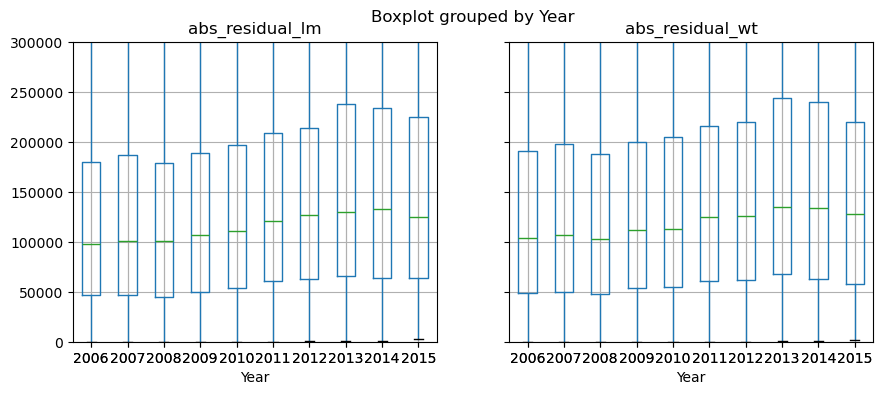

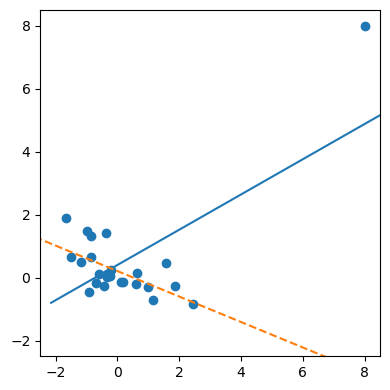

In [2111]:
%matplotlib inline
from scipy.stats import linregress #SciPy’s quick simple linear regression function (1 x vs 1 y).

np.random.seed(5)
x = np.random.normal(size=25)
y = -x / 5 + np.random.normal(size=25)
x[0] = 8
y[0] = 8
'''
Fixes the random seed for reproducibility.
Makes 25 random x’s (Normal(0,1)).
Makes y with a true slope ≈ −0.2 plus noise.
Overwrites the first point to (8, 8) → a deliberate outlier.
'''
def abline(slope, intercept, ax):
    """Calculate coordinates of a line based on slope and intercept"""
    x_vals = np.array(ax.get_xlim())
    return (x_vals, intercept + slope * x_vals)
'''
Helper: given slope/intercept and an Axes, take the current x-range (ax.get_xlim()), and return (x, y) points for that straight line across the axis span.
'''


fig, ax = plt.subplots(figsize=(4, 4))
ax.scatter(x, y) # plots the data points.
slope, intercept, _, _, _ = linregress(x, y) # slope, intercept, r (Pearson’s correlation coefficient), p-value, and standard errors
ax.plot(*abline(slope, intercept, ax))
'''
Fits simple linear regression to all points; grabs the slope & intercept (ignores r, p, stderr with _).
Plots the fitted line across the current x-limits. (* unpacks the (x_vals, y_vals) tuple.)
'''
slope, intercept, _, _, _ = linregress(x[1:], y[1:])
ax.plot(*abline(slope, intercept, ax), '--')
'''
Fits the line again, excluding the outlier (uses elements 1..end).
Plots this second line as dashed, so you can see how the outlier changes the fit.
'''
ax.set_xlim(-2.5, 8.5)
ax.set_ylim(-2.5, 8.5)

plt.tight_layout()
plt.show()


`scipy.stats.linregress` uses the classic simple-OLS formulas (with an intercept). Let $n$ be the number of paired points $(x_i, y_i)$.

Compute the usual sums:

$$
\bar{x} = \frac{1}{n} \sum x_i, \quad \bar{y} = \frac{1}{n} \sum y_i, \quad S_{xx} = \sum (x_i - \bar{x})^2, \quad S_{xy} = \sum (x_i - \bar{x})(y_i - \bar{y}).
$$

OLS estimates:

$$
\hat{\beta}_1 = \frac{S_{xy}}{S_{xx}} \quad \text{(slope)}, \qquad \hat{\beta}_0 = \bar{y} - \hat{\beta}_1 \bar{x} \quad \text{(intercept)}.
$$

Residuals and residual variance:

$$
e_i = y_i - (\hat{\beta}_0 + \hat{\beta}_1 x_i), \quad \hat{\sigma}^2 = s^2 = \frac{\sum e_i^2}{n-2}.
$$

Standard error of the slope (what linregress returns as `se` or `stderr`):

$$
\text{SE}(\hat{\beta}_1) = \frac{s}{\sqrt{S_{xx}}}.
$$

Standard error of the intercept (what linregress returns as `intercept_se` or `intercept_stderr`):

$$
\text{SE}(\hat{\beta}_0) = s \sqrt{\frac{1}{n} + \frac{\bar{x}^2}{S_{xx}}}.
$$

These follow from 

$$
\operatorname{Var}(\hat{\beta}_1) = \frac{\sigma^2}{S_{xx}}
$$

and

$$
\operatorname{Var}(\hat{\beta}_0) = \sigma^2 \left(\frac{1}{n} + \frac{\bar{x}^2}{S_{xx}}\right),
$$

with $\sigma^2$ estimated by $s^2$ (degrees of freedom = $n-2$).


<span style="color:gold; font-size:1.5em; font-weight:bold;">

The package `statsmodel` provides a number of plots to analyze the data point influence
</span>

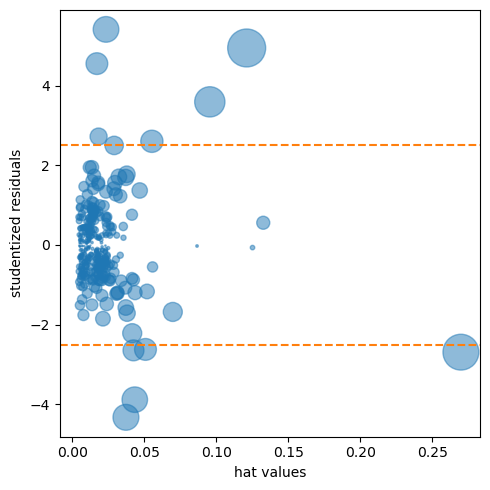

In [2112]:
influence = OLSInfluence(result_98105)
fig, ax = plt.subplots(figsize=(5, 5))
ax.axhline(-2.5, linestyle='--', color='C1')
ax.axhline(2.5, linestyle='--', color='C1')
ax.scatter(
    influence.hat_matrix_diag,                    # x: leverage h_ii
    influence.resid_studentized_internal,         # y: studentized residual r_i
    s=1000 * np.sqrt(influence.cooks_distance[0]),# bubble size: ∝ √(Cook’s D)
    alpha=0.5
)
# Make the influence plot:
# x-axis = leverage hii → how unusual the predictors are.
# y-axis = internally studentized residual ri → how unusual the error is.
# marker size ∝ sqrt(Di) (Cook’s distance). (cooks_distance returns (values, pvals), so [0] grabs the values.)
# Using sqrt(D) compresses extremes so bubbles aren’t huge.

ax.set_xlabel('hat values')
ax.set_ylabel('studentized residuals')

plt.tight_layout()
plt.show()

In [2113]:
influence.cooks_distance[0].sort_values(ascending=False)

14384    5.607885e-01
26040    4.459139e-01
26043    2.267787e-01
24333    1.209192e-01
14392    1.172666e-01
             ...     
24341    7.969412e-07
17151    7.949328e-07
14375    7.522923e-07
14432    2.902196e-07
24398    1.746525e-07
Length: 313, dtype: float64

In [2114]:
house_98105.loc[[1036, 1769]]

,DocumentDate,SalePrice,PropertyID,PropertyType,ym,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,...,YrBuilt,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode,NewConstruction,Year,Weight,ZipGroup
1036,2007-08-16,825000,394500005,Multiplex,2007-08-01,434600,0.998621,826139.0,2,7245,...,1961,0,2,280000,468000,98105,False,2007,2,4
1769,2006-12-27,655000,714000130,Single Family,2006-12-01,423400,0.972886,673255.0,1,6750,...,1946,0,0,350000,417000,98105,False,2006,1,4


In [2115]:
house_98105.iloc[:2].loc[[True, False]]

,DocumentDate,SalePrice,PropertyID,PropertyType,ym,zhvi_px,zhvi_idx,AdjSalePrice,NbrLivingUnits,SqFtLot,...,YrBuilt,YrRenovated,TrafficNoise,LandVal,ImpsVal,ZipCode,NewConstruction,Year,Weight,ZipGroup
1036,2007-08-16,825000,394500005,Multiplex,2007-08-01,434600,0.998621,826139.0,2,7245,...,1961,0,2,280000,468000,98105,False,2007,2,4


In [2116]:
mask = [dist < .08 for dist in influence.cooks_distance[0]]
house_infl = house_98105.loc[mask]

ols_infl = sm.OLS(house_infl[outcome], house_infl[predictors].assign(const=1))
result_infl = ols_infl.fit()

pd.DataFrame({
    'Original': result_98105.params,
    'Influential removed': result_infl.params,
})

,Original,Influential removed
Bathrooms,2282.264145,-16131.879785
Bedrooms,-26320.268796,-22887.865318
BldgGrade,130000.099737,114870.559737
SqFtLot,38.933315,33.141600
SqFtTotLiving,209.602346,230.052569
const,-772549.862447,-647137.096716


## **Heteroskedasticity, Non-Normality and Correlated Errors**  

The `regplot` in seaborn allows adding a lowess smoothing line to the scatterplot.

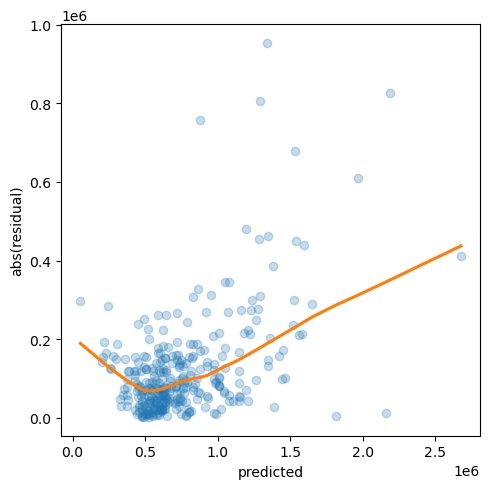

In [2117]:
fig, ax = plt.subplots(figsize=(5,5))
sns.regplot(
    x=result_98105.fittedvalues,          # x-axis = model’s in-sample predictions ŷ
    y=np.abs(result_98105.resid),         # y-axis = absolute residuals |y - ŷ|
    scatter_kws={'alpha': 0.25},          # lighter points (25% opacity) to reduce overplotting
    line_kws={'color': 'C1'},             # color for the smooth curve
    lowess=True,                          # draw a LOWESS (locally weighted) smooth, not a straight line
    ax=ax
)
'''
sns.regplot draws a scatter and a trend line.
With lowess=True, it fits a nonparametric LOWESS smooth (good for visualizing the average pattern of |residual| vs ŷ).
Plotting |residual| against fitted is a classic scale-location (spread–location) (Heteroskedasticity) check: does the error spread change with the prediction?
'''
ax.set_xlabel('predicted')
ax.set_ylabel('abs(residual)')

plt.tight_layout()
plt.show()

**How to interpret this plot**  

You’re looking for heteroskedasticity (non-constant variance).  

If the LOWESS curve is flat and the cloud (i.e., the swarm of dots) has roughly constant vertical spread across the x-range, variance looks about constant.  

If you see a funnel (spread grows with ŷ) or the LOWESS line rises with ŷ, that suggests heteroskedasticity.  

Curvature or pockets can also hint at missing structure (e.g., nonlinearity, interactions, or omitted variables like location).

**Variants / tips**  

Many textbooks use $\sqrt{|e_i|}$ or studentized residuals on the y-axis:

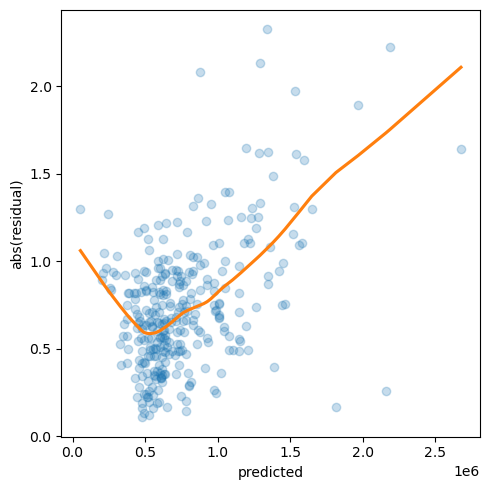

In [2118]:
fig, ax = plt.subplots(figsize=(5,5))
yplot = np.sqrt(np.abs(OLSInfluence(result_98105).resid_studentized_internal))
sns.regplot(x=result_98105.fittedvalues, y=yplot, lowess=True, scatter_kws={'alpha':0.25}, line_kws={'color':'C1'}, ax=ax)
ax.set_xlabel('predicted')
ax.set_ylabel('abs(residual)')

plt.tight_layout()
plt.show()

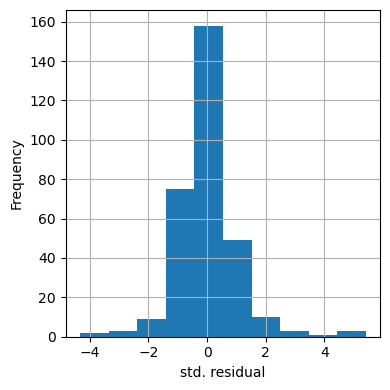

In [2119]:
fig, ax = plt.subplots(figsize=(4, 4))
pd.Series(influence.resid_studentized_internal).hist(ax=ax)
ax.set_xlabel('std. residual')
ax.set_ylabel('Frequency')
'''
Takes the internally studentized residuals (one per observation) from your OLSInfluence object,
wraps them in a pandas Series, and plots a histogram on ax.
“std. residual” here means ri = e_i / (s * sqrt(1 - h_ii)):
residuals scaled by their estimated standard deviation (so they’re comparable across points).
'''
plt.tight_layout()
plt.show()

### How to interpret the histogram

- Under the classical OLS assumptions, studentized residuals should be roughly symmetric around 0 with a bell-ish shape.
- Heavy tails (too many large |values|) or skew (more mass on one side) suggest non-normal errors, outliers, or misspecification (e.g., need log-transform, nonlinearity, missing features like location).
- Big bars beyond about ±2 to ±3 indicate potential outliers (screen with externally studentized residuals for formal tests).

By “big bars beyond ±2 to ±3” I mean this, in your histogram of studentized residuals:
- The x-axis is the residual value (e.g., −4, −3, …, 0, …, 3, 4).
- The histogram bars (bins) far out in the tails—i.e., bins whose centers are less than −2 or greater than +2 (and especially beyond ±3)—show how many observations have unusually large residuals.

**Why those cutoffs?**

Under the usual OLS/normal-errors setup, studentized residuals behave like a t-statistic with many degrees of freedom, so:
- About 95% should lie within ±2.
- About 99.7% should lie within ±3.

So with $n=313$, you’d expect roughly:
- ≈5% outside ±2 → ~16 points total.
- ≈0.3% outside ±3 → ~1 point total.

If your histogram shows tall bars out past ±2 or especially ±3 (i.e., more points than roughly expected), that suggests heavy tails / outliers or model misspecification (e.g., heteroskedasticity, nonlinearity, missing variables).


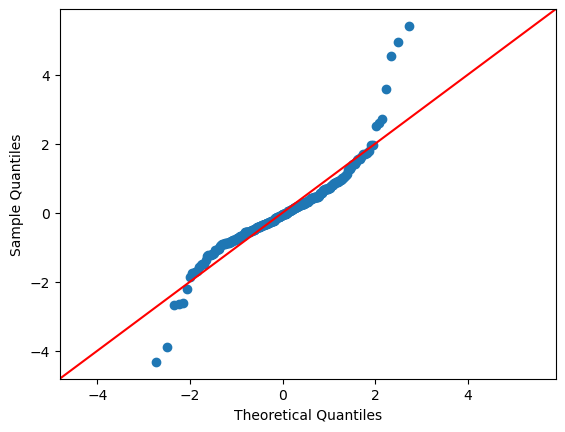

In [2120]:
import statsmodels.api as sm
sm.ProbPlot(influence.resid_studentized_internal).qqplot(line='45') # Interpretation: if residuals are approximately normal, the points will lie close to the 45° line.


**What it shows:**

- **Tails bend away from the line:** points are well below the line on the left and well above on the right. → **Heavier tails than Normal (leptokurtic) and some outliers**.

- **The center is closer to the line than the extremes.** → Most residuals are OK, but the extremes are too extreme relative to Normal.

- **The right tail appears to deviate a bit more than the left.** → Mild right‐skew in residuals (model underpredicts a few expensive homes).

- `influence.resid_studentized_internal` do not have an exact t-distribution. They use the full-sample $s$ in the denominator, so their distribution isn’t exactly t (though for large $n$ it often approximates Normal/t).
  
- The ones that do follow a t-distribution (under the usual OLS normal-error assumptions) are the **externally studentized residuals**:

$$
t_i = \frac{e_i}{\,s_{(i)}\sqrt{1-h_{ii}}\,} \sim t_{n-p-2},
$$

where $s_{(i)}$ is computed *after* leaving observation $i$ out. Use:
```python
t_ext = influence.resid_studentized_external # has t_{n-p-2} dist (under normality)
```

If you want a Q–Q plot against the appropriate t:
```python
df = int(result_98105.df_resid) - 1 # n - p - 2
sm.ProbPlot(t_ext, dist='t', distargs=(df,)).qqplot(line='45')
```

**Rule of thumb:** use internal for quick screening/plots; use external for formal outlier tests (e.g., `results.outlier_test()`).


**What it shows**  

- X-axis: theoretical quantiles from the reference distribution.

- Y-axis: sample quantiles from your data.

- Straight line ≈ good match.

- Upward curve at ends: heavier tails than Normal.

- Downward curve at ends: lighter tails.

- Overall S-shape: skewness.

- Few far-off points: potential outliers.

## **Partial Residual Plots and Nonlinearity**

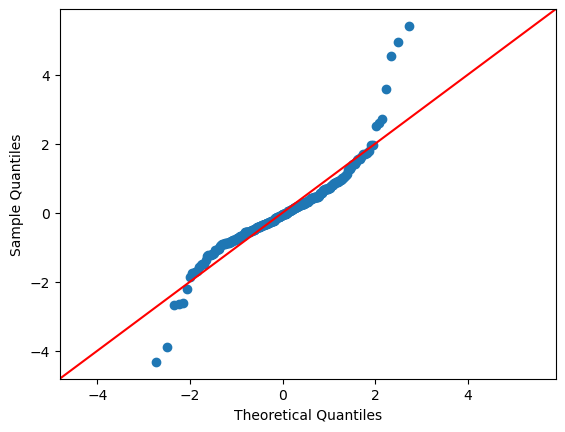

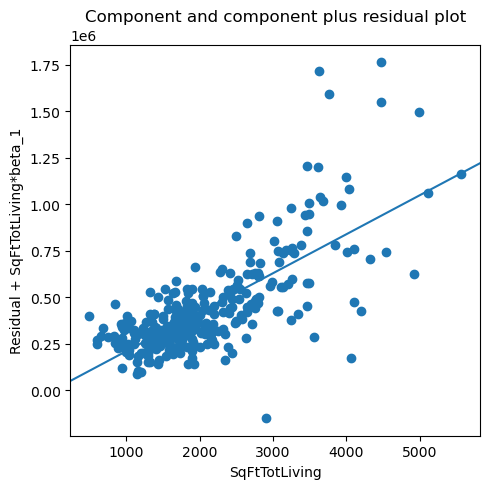

In [2121]:
fig, ax = plt.subplots(figsize=(5, 5))
fig = sm.graphics.plot_ccpr(result_98105, 'SqFtTotLiving', ax=ax)

plt.tight_layout()
plt.show()

Add a smooth to check curvature:

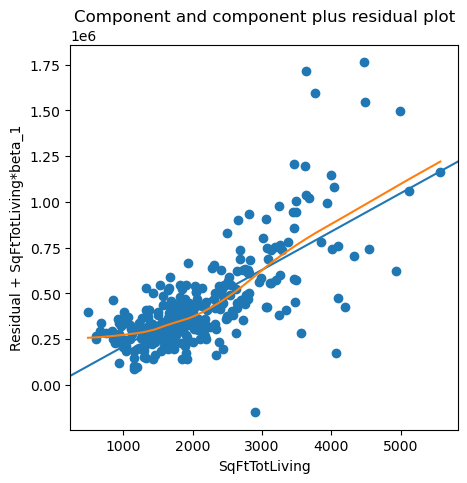

In [2122]:
fig, ax = plt.subplots(figsize=(5, 5))
fig = sm.graphics.plot_ccpr(result_98105, 'SqFtTotLiving', ax=ax)
from statsmodels.nonparametric.smoothers_lowess import lowess
x = house_98105['SqFtTotLiving']
pr = result_98105.resid + result_98105.params['SqFtTotLiving'] * x
smoothed = lowess(pr, x, frac=0.6)
plt.plot(smoothed[:,0], smoothed[:,1], color='C1')

plt.tight_layout()
plt.show()

If the smooth bends away from the straight line, consider nonlinearity (e.g., splines or log(SqFtTotLiving)).  

If spread increases with size, consider modeling log(price) or using heteroskedasticity-robust SEs (cov_type="HC3").

Inspect the few extreme points with leverage/Cook’s D to see how much they influence the fit.  

Bottom line: the linear term for SqFtTotLiving looks broadly reasonable, with signs of bigger variance at high square footage and a handful of influential outliers worth checking.

This code:

```python
from statsmodels.nonparametric.smoothers_lowess import lowess
x = house_98105['SqFtTotLiving']
pr = result_98105.resid + result_98105.params['SqFtTotLiving'] * x
smoothed = lowess(pr, x, frac=0.6)
plt.plot(smoothed[:,0], smoothed[:,1], color='C1')
```

draws a **LOWESS smooth** of the partial residuals for `SqFtTotLiving`.  

It’s a nonparametric estimate of how the response varies with `SqFtTotLiving` after controlling for the other predictors—**used to check whether a linear effect is adequate.**  


**Line by line:**
```python
x = house_98105['SqFtTotLiving']
```
- The focal predictor $x_j$.
```python
pr = result_98105.resid + result_98105.params['SqFtTotLiving'] * x
```
- The partial residuals for $x_j$:
  $$
  \text{PR}_i = \hat{e}_i + \hat{\beta}_j x_{ij} = y_i - \left( \hat{\beta}_0 + \sum_{k \ne j} \hat{\beta}_k x_{ik} \right )
  $$
- This removes the fitted contribution of other predictors, leaving the part of $y$ associated with `SqFtTotLiving` (plus noise).
```python
smoothed = lowess(pr, x, frac=0.6)
```
- **LOWESS** (locally weighted regression) smooths PR vs x.  
  frac=0.6 sets the bandwidth (each local fit uses 60% of the data) → a fairly smooth curve.
- `smoothed` is a 2-column array: first column sorted $x$, second the smoothed $\widehat{\text{PR}}(x)$.
```python
plt.plot(smoothed[:,0], smoothed[:,1], color='C1')
```
- Plots the smooth curve on the CCPR axes.


### How to read the curve

- If the curve is approximately a straight line with slope near $\hat{\beta}_j$, the linear term for SqFtTotLiving looks adequate (given the other predictors).
- If it bends (concave/convex, S-shape), there’s evidence of nonlinearity—consider transformations (e.g., $\log$), polynomial/spline terms, or interactions.
- Changing vertical spread around the curve suggests heteroskedasticity (though the smooth itself shows the mean trend).

**In short:**  
That curve is a data-driven estimate of the conditional mean trend of price vs. SqFtTotLiving after partialing out the rest; deviations from a straight line flag that the linear specification may be missing curvature.


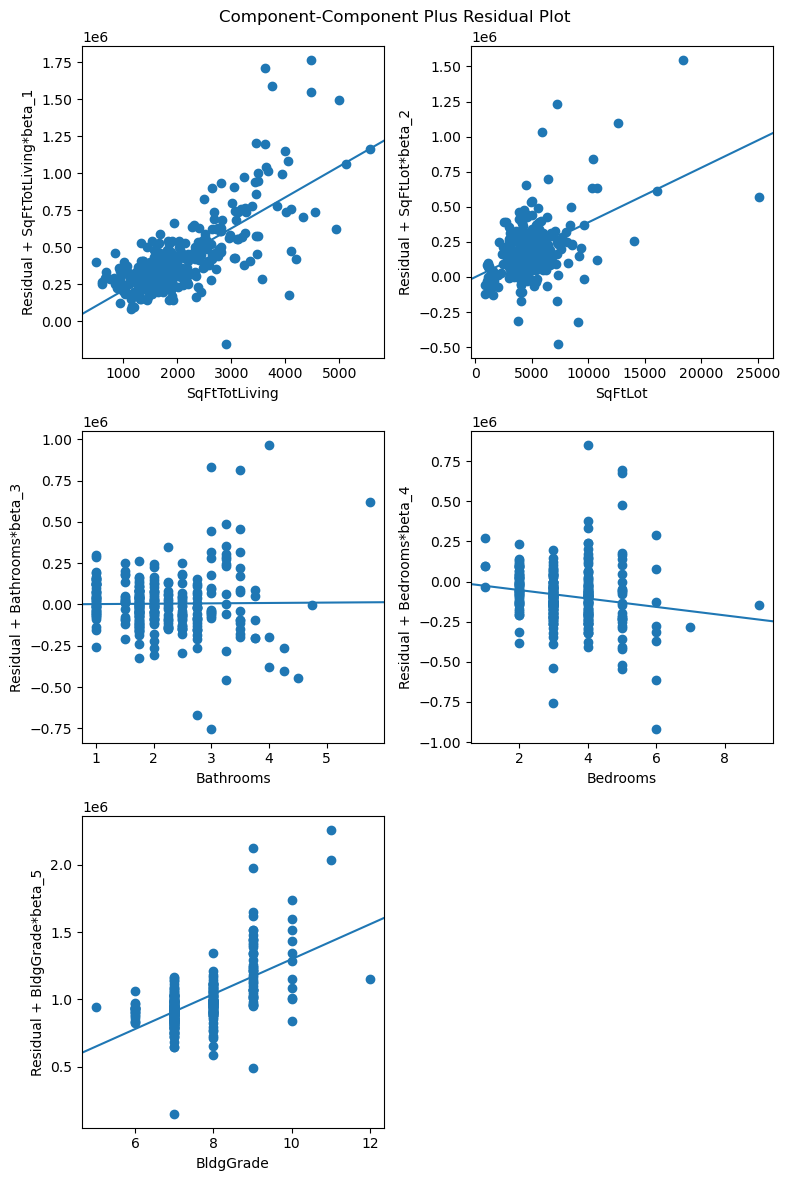

In [2123]:
fig = plt.figure(figsize=(8, 12))
# fig = sm.graphics.plot_ccpr(result_98105, 'SqFtTotLiving', ax=ax)
fig = sm.graphics.plot_ccpr_grid(result_98105, fig=fig)
from statsmodels.nonparametric.smoothers_lowess import lowess
x = house_98105['SqFtTotLiving']
pr = result_98105.resid + result_98105.params['SqFtTotLiving'] * x
smoothed = lowess(pr, x, frac=0.6)
plt.plot(smoothed[:,0], smoothed[:,1], color='C1')

plt.tight_layout()
plt.show()

We can overlay a LOWESS curve on each CCPR panel by looping over the axes and the corresponding regressors used in the grid.  

The key is that a CCPR plot’s y-axis is the partial residual for regressor $j$:

$$
\text{partial}_j = \text{resid} + \hat{\beta}_j x_j.
$$

So we compute that for each regressor and draw a LOWESS line on the matching axis.


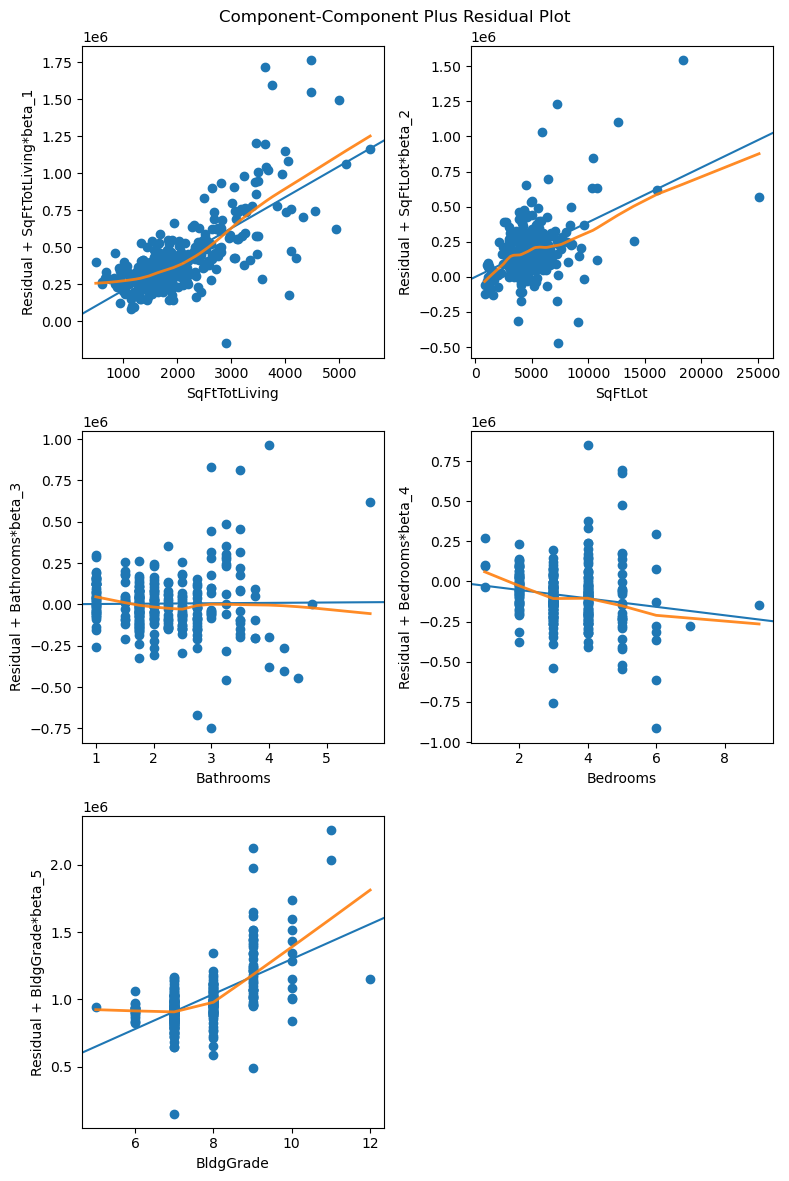

In [2124]:
from statsmodels.nonparametric.smoothers_lowess import lowess
# predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms','BldgGrade']
# Fit (already done)
# result_98105 = smf.ols(...).fit()

cont_vars = ["SqFtTotLiving", "SqFtLot", "Bathrooms", "Bedrooms", "BldgGrade"] # A list of the predictor names we want CCPR panels for (and in this order).

# Build CCPR grid by variable NAMES (works in recent statsmodels)
fig = sm.graphics.plot_ccpr_grid(
    result_98105,
    # we’re telling plot_ccpr_grid which predictor variables (cont_vars) we want to plot the component and component-plus-residual (CCPR) plots for:
    exog_idx=cont_vars, #exog stands for exogenous variables — that’s just another name for the independent variables / predictors / features in your regression model.
    fig=plt.figure(figsize=(8, 12))
)
'''
Builds a CCPR grid (Component & Component-Plus-Residual plots) for your fitted OLS model result_98105.
exog_idx=cont_vars tells statsmodels which predictors to plot—by name (works in recent versions).
fig=plt.figure(figsize=(8, 12)) pre-allocates an 8×12 inch figure to draw into.
Returns the populated Matplotlib Figure; the subplots are in fig.axes (one axis per variable).
'''

# Indices of rows actually used in the fit (after any NA drops)
idx = result_98105.resid.index # Gets the row index of the residuals (a pandas.Index). This is the set/order of rows actually used in the fit after any NA drops, ensuring later alignment with our original DataFrame.
resid = result_98105.resid.to_numpy() #Converts residuals (a pd.Series) to a NumPy array for fast numeric ops.

# Overlay LOWESS on each panel
for ax, var in zip(fig.axes, cont_vars):
    xj = house_98105.loc[idx, var].to_numpy()  # pull x from our original DF, aligned to used rows. Pulls the predictor column var from our original DataFrame restricted to the used rows (idx) so xj lines up 1-to-1 with resid.
    m = np.isfinite(xj) & np.isfinite(resid) # Boolean mask: keep only observations where both xj and resid are finite (no NaN/Inf). This avoids crashes and spurious wiggles in the smoother.
    partial = resid[m] + result_98105.params[var] * xj[m]
    '''
    Computes the partial residuals for variable var:
    PR_j = r + β̂_j x_j
    This is exactly what CCPR uses on the y-axis.
    '''
    smth = lowess(partial, xj[m], frac=0.6, it=1, return_sorted=True)
    '''
    Runs LOWESS (locally weighted regression) of partial on xj.
    frac=0.6 controls smoothness (window ≈ 60% of the data; raise to smooth more, lower to follow detail).
    return_sorted=True returns points sorted by x so plotting draws a clean curve.

    it = number of robustifying iterations in LOWESS.
    LOWESS first fits a local weighted regression (using distance weights).
    Then, for robustness, it can down-weight outliers based on the previous fit’s residuals using a Tukey/bi-square function (residuals are scaled by a robust scale like MAD).
    Setting it=1 means: after the initial smooth, do one extra robust pass—compute residuals → compute robustness weights → refit once.
    it=0: no robustness (plain LOWESS).
    it=1: mildly robust (often enough).
    it≥2: stronger outlier down-weighting (slower, sometimes overkill).
    Rule of thumb: start with it=1 (or your library’s default), increase only if you still see outlier-driven wiggles. If you’re unsure of the default in your statsmodels version, check help(lowess) in your environment.
    '''
    ax.plot(smth[:, 0], smth[:, 1], linewidth=2, alpha=0.9) # Overlays the LOWESS curve (x = smth[:,0], y = smth[:,1]) on the current CCPR panel.

plt.tight_layout()
plt.show()




In [2125]:
result_98105.params["SqFtLot"]

np.float64(38.93331499818081)

## **Polynomial and Spline Regression**

In [2126]:
model_poly = smf.ols(formula='AdjSalePrice ~  SqFtTotLiving + np.power(SqFtTotLiving, 2) + SqFtLot + Bathrooms + Bedrooms + BldgGrade', data=house_98105)
result_poly = model_poly.fit()
print(result_poly.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.806
Model:                            OLS   Adj. R-squared:                  0.802
Method:                 Least Squares   F-statistic:                     211.6
Date:                Mon, 15 Sep 2025   Prob (F-statistic):          9.95e-106
Time:                        03:21:47   Log-Likelihood:                -4217.9
No. Observations:                 313   AIC:                             8450.
Df Residuals:                     306   BIC:                             8476.
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

The `statsmodels` implementation of a partial residual plot works only for linear term. Here is an implementation of a partial residual plot that, while inefficient, works for the polynomial regression.


In [2127]:
house_98105.columns

Index(['DocumentDate', 'SalePrice', 'PropertyID', 'PropertyType', 'ym',
       'zhvi_px', 'zhvi_idx', 'AdjSalePrice', 'NbrLivingUnits', 'SqFtLot',
       'SqFtTotLiving', 'SqFtFinBasement', 'Bathrooms', 'Bedrooms',
       'BldgGrade', 'YrBuilt', 'YrRenovated', 'TrafficNoise', 'LandVal',
       'ImpsVal', 'ZipCode', 'NewConstruction', 'Year', 'Weight', 'ZipGroup'],
      dtype='object')

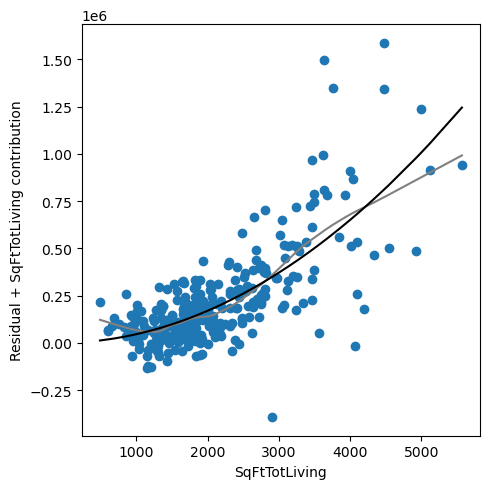

0.03879128168237212


In [2128]:
def partialResidualPlot(model, df, outcome, feature, ax): # Define a helper that will draw on an existing Matplotlib axis.
    y_pred = model.predict(df) # Compute fitted values y^ from the full model on the full data.
    # determine columns required for model
    required = set(model.params.index).intersection(df.columns)
    '''
    model.params.index → the names of the fitted coefficients (e.g., "Intercept", "SqFtTotLiving", "np.power(SqFtTotLiving, 2)", "Bathrooms", …).
    df.columns → the column names actually present in our DataFrame.
    set(...).intersection(...) builds a set of names that appear in BOTH places.
    In plain English: “keep only those parameter names that are also raw columns in df.”
    (This excludes derived terms like "np.power(SqFtTotLiving, 2)" because that’s not a raw column.)
    '''
    required.add(feature)
    '''
    Make sure the raw feature (e.g., "SqFtTotLiving") is definitely included, even if it wasn’t in model.params.index under that exact name (e.g., because the model used only the squared term or a transformation).
    This is crucial so the formula machinery can recompute transforms (like the square) from the raw feature.
    '''
    copy_df = df[list(required)].copy().astype('float')
    '''
    Take just those columns into a new DataFrame: subset → copy → cast to float (prevents dtype issues).
    We’ll later zero out all columns except feature to isolate the feature’s modeled contribution.
    '''
    for c in copy_df.columns:
        if c == feature:
            continue
        copy_df.loc[:, c] = 0.0
    feature_prediction = model.predict(copy_df)
    '''
    Predict again, now with only the feature “turned on”. 
    This returns β_0 + f_j(x_ij), i.e., the intercept plus the feature’s contribution (including its polynomial terms).
    in our case: f(x) = β_1 x + β_2 x^2
    '''
    intercept_name = next(n for n in model.params.index if n.lower() in ('intercept','const'))
    '''
    model.params.index — the names of the fitted coefficients (a pandas Index), e.g. ['Intercept', 'SqFtTotLiving', 'np.power(SqFtTotLiving, 2)', 'Bathrooms'].
    n for n in model.params.index if ... — a generator expression that yields each name n whose lowercase version matches either 'intercept' or 'const'.
    (Statsmodels sometimes calls the intercept "Intercept" when using formulas, or "const" when we added a constant via sm.add_constant.)
    next(...) — returns the first matching name from that generator.
    '''
    results = pd.DataFrame({
        'feature': df[feature],
        'residual': df[outcome] - y_pred,
        'ypartial': feature_prediction - model.params[intercept_name]
    })
    '''
    Assemble what we need:
    feature: x-values.
    residual: y - ŷ from the full model.
    ypartial: subtract the intercept from feature_prediction to leave only the feature’s contribution f_j(x_ij).
    (model.params.iloc[0] is assumed to be the intercept.)
    '''
    results = results.sort_values(by=['feature']) # Sort by x so lines plot cleanly.

    # smoothed = sm.nonparametric.lowess(results.ypartial, results.feature, frac=1/3)
    smoothed = sm.nonparametric.lowess(
        results.ypartial + results.residual,  # PR_i(x)
        results.feature,
        frac=1/3
    )

    ax.scatter(results.feature, results.ypartial + results.residual)
    ax.plot(smoothed[:, 0], smoothed[:, 1], color='gray') # Overlay the LOWESS curve (gray).
    ax.plot(results.feature, results.ypartial, color='black') # Overlay the model’s fitted component for feature (black). This is what our parametric form (e.g., linear + quadratic) implies.
    ax.set_xlabel(feature)
    ax.set_ylabel(f'Residual + {feature} contribution')
    return ax

fig, ax = plt.subplots(figsize=(5, 5))
# house_98105 = house.loc[house['ZipCode'] == 98105, ]
partialResidualPlot(result_poly, house_98105, 'AdjSalePrice', 'SqFtTotLiving', ax) # so the gray curve summarizes the scatter you just plotted.

plt.tight_layout()
plt.show()
print(result_poly.params.iloc[2]) # Draw the plot for SqFtTotLiving and print the third parameter in our model (index 2). In our polynomial model that’s typically the quadratic coefficient.

## **Splines**

In [2129]:
from patsy import bs
formula = ('AdjSalePrice ~ bs(SqFtTotLiving, df=6, degree=3) + ' + 
           'SqFtLot + Bathrooms + Bedrooms + BldgGrade')
model_spline = smf.ols(formula=formula, data=house_98105)
result_spline = model_spline.fit()
print(result_spline.summary())

                            OLS Regression Results                            
Dep. Variable:           AdjSalePrice   R-squared:                       0.814
Model:                            OLS   Adj. R-squared:                  0.807
Method:                 Least Squares   F-statistic:                     131.8
Date:                Mon, 15 Sep 2025   Prob (F-statistic):          7.10e-104
Time:                        03:21:48   Log-Likelihood:                -4211.4
No. Observations:                 313   AIC:                             8445.
Df Residuals:                     302   BIC:                             8486.
Df Model:                          10                                         
Covariance Type:            nonrobust                                         
                                           coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------------


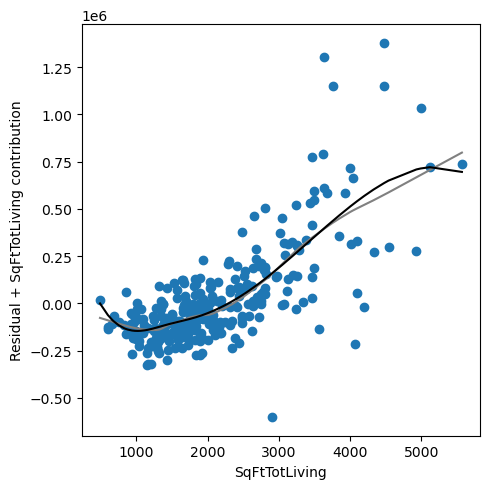

In [2130]:
fig, ax = plt.subplots(figsize=(5, 5))
partialResidualPlot(result_spline, house_98105, 'AdjSalePrice', 'SqFtTotLiving', ax)

plt.tight_layout()
plt.show()

## **Generalized Additive Models**

### **Using statsmodels**

In [2131]:
from statsmodels.gam.api import GLMGam, BSplines # Import the GAM model class and the B-spline smoother constructor from statsmodels.

# linear-only predictors
lin = ['SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade'] # the predictors we’ll keep linear (parametric).

# smooth only on SqFtTotLiving
bs = BSplines(house_98105[['SqFtTotLiving']], df=[10], degree=[3])
'''
Build a cubic B-spline basis (degree 3) for the single column SqFtTotLiving.
df=[10] → use 10 basis functions for this smooth (more = more flexibility/variance).
Knots are placed automatically (quantile-like) unless we override.
'''
alpha = [10.0]  # tune via CV/AIC/BIC # this is λ for the statsmodels smoother
# Set the smoothing penalty weight (λ) for that smooth term. Larger = smoother curve; smaller = wigglier. One value because there’s one smooth.
# the penalty shrinks wiggliness of the smooth during fitting; it doesn’t appear in 𝑦^ explicitly.
gam = GLMGam.from_formula(
    'AdjSalePrice ~ ' + ' + '.join(lin),
    data=house_98105, smoother=bs, alpha=alpha
)
'''
# Define the model:
# Formula gives the linear part: AdjSalePrice ~ SqFtLot + Bathrooms + Bedrooms + BldgGrade (intercept included by default).
# smoother=bs adds the nonlinear smooth s(SqFtTotLiving).
# By default, this is a Gaussian (identity link) GAM unless we pass a different family.
# Mathematically:
#   E[y] = β_0 + β^T X_linear + s(SqFtTotLiving),
# with a roughness penalty λ∫(s''(x))^2 dx controlled by alpha.

'''
res = gam.fit() # Fit the penalized model (IRLS / penalized least squares), estimating both the linear coefficients and the spline coefficients subject to the smoothing penalty.
print(res.summary())

                 Generalized Linear Model Regression Results                  
Dep. Variable:           AdjSalePrice   No. Observations:                  313
Model:                         GLMGam   Df Residuals:                   299.00
Model Family:                Gaussian   Df Model:                        13.00
Link Function:               Identity   Scale:                      2.9585e+10
Method:                         PIRLS   Log-Likelihood:                -4210.3
Date:                Mon, 15 Sep 2025   Deviance:                   8.8459e+12
Time:                        03:21:48   Pearson chi2:                 8.85e+12
No. Iterations:                     3   Pseudo R-squ. (CS):             0.9851
Covariance Type:            nonrobust                                         
                       coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept        -4.842e+05   1.58e+05  

we see 9 coefficients printed because of an identifiability tweak in statsmodels. We asked for df=10 basis functions, and we did get a 10-dimensional spline space—but by default `statsmodels` removes the constant piece from the spline basis to avoid perfect collinearity with the model’s intercept. It does that by dropping one basis column, so we see 9 coefficients printed:

df=10 = 10 basis functions before constraints

default `include_intercept=False, constraints=None` ⇒ “remove the constant in the spline basis by dropping one column” ⇒ 9 printed columns: SqFtTotLiving_s0 … s8.

This one line:
```python
gam = GLMGam.from_formula(
    'AdjSalePrice ~ ' + ' + '.join(lin),
    data=house_98105, smoother=bs, alpha=alpha
)
```

is building the GAM model object. Here’s exactly what each piece means:

- **`GLMGam.from_formula(...)`**  
  Constructs a Generalized Additive Model (GAM) using a Patsy-style formula for the linear (parametric) part, plus a separate smoother object for the non-linear part(s).

- **Formula: `'AdjSalePrice ~ ' + ' + '.join(lin)`**  
  If `lin = ['SqFtLot','Bathrooms','Bedrooms','BldgGrade']`, this becomes  
  `"AdjSalePrice ~ SqFtLot + Bathrooms + Bedrooms + BldgGrade"`.  
  That tells `statsmodels` to include an intercept and linear coefficients for those four predictors.

- **`data=house_98105`**  
  The DataFrame that supplies the variables named in the formula.

- **`smoother=bs`**  
  Adds the smooth (nonlinear) part(s) of the model. We built `bs` just above with:  
```python
bs = BSplines(house_98105[['SqFtTotLiving']], df=, degree=)
```
That means: make a cubic B-spline smooth for `SqFtTotLiving` with 10 basis functions.  
Even though `SqFtTotLiving` isn’t in the formula string, it is in the model via this smoother.

- **`alpha=alpha`**  
Sets the smoothing penalty weight(s) for the smooth terms.  
We set `alpha = [10.0]`, i.e., one smooth → one λ.  
Larger values ⇒ smoother (less wiggly) $s(\cdot)$; smaller values ⇒ more flexible.

Put together, the model we’ve specified is:

$$
\underbrace{\mathbb{E}[Y\mid X]}_{\text{Gaussian identity}} \;=\; \beta_0 \;+\; \beta_1\,\text{SqFtLot} \;+\; \beta_2\,\text{Bathrooms} \;+\; \beta_3\,\text{Bedrooms} \;+\; \beta_4\,\text{BldgGrade} \;+\; s(\text{SqFtTotLiving}),
$$

with a roughness penalty on $s(\cdot)$ controlled by `alpha`.

>**“Gaussian identity $E[Y \mid X]$”** is just shorthand for:  
a Normal-error GAM with the identity link, where the model directly specifies the conditional mean $E[Y \mid X]$ as the additive predictor.


This line **doesn’t fit** the model yet—it just defines it.  
The next line, `res = gam.fit()`, actually estimates the parameters under that penalty.


<>:52: SyntaxWarning: invalid escape sequence '\h'
<>:52: SyntaxWarning: invalid escape sequence '\h'
/var/folders/5f/dq45wr613kb8f2bwp4zr0gpc0000gn/T/ipykernel_2325/798181798.py:52: SyntaxWarning: invalid escape sequence '\h'
  # Solid line: the GAM smooth $\hat{f}(x)$ evaluated on a clean grid.
  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


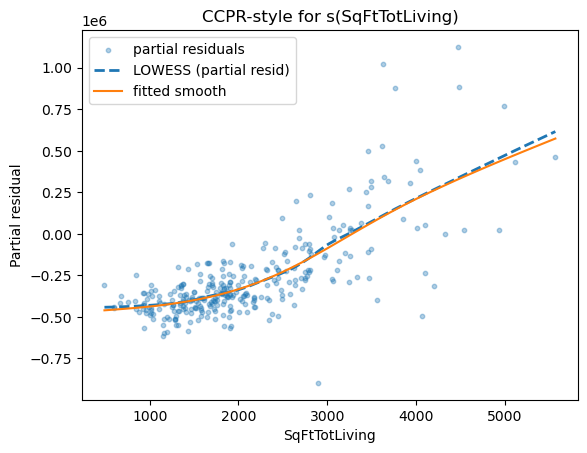

LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      7.6772
Link Function:                     IdentityLink Log Likelihood:                                 -7833.1159
Number of Samples:                          313 AIC:                                            15683.5863
                                                AICc:                                             15684.14
                                                GCV:                                      30838885095.1707
                                                Scale:                                    29480381715.8322
                                                Pseudo R-Squared:                                   0.8117
Feature Function                  Lam

/var/folders/5f/dq45wr613kb8f2bwp4zr0gpc0000gn/T/ipykernel_2325/798181798.py:56: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam.summary())


In [2132]:
from pygam import LinearGAM, s, l

predictors = ['SqFtTotLiving','SqFtLot','Bathrooms','Bedrooms','BldgGrade']
X = house_98105[predictors].to_numpy()
y = house_98105['AdjSalePrice'].to_numpy()
'''
LinearGAM = a GAM with Gaussian errors + identity link (OLS-like).
s(i) = a smooth term on column i of X.
l(i) = a linear (parametric) term on column i.
X is our design matrix (n×5), y the target (n,).
'''
# model: smooth for SqFtTotLiving, linear for others — with auto-tuned smoothing
gam = LinearGAM(s(0, n_splines=12) + l(1) + l(2) + l(3) + l(4)).gridsearch(X, y)

# --- per-term fitted contributions (R: predict(..., type='terms')) ---
# skip the intercept term
non_intercept = [i for i, t in enumerate(gam.terms) if not getattr(t, 'isintercept', False)]
terms = np.column_stack([gam.partial_dependence(term=i, X=X) for i in non_intercept])
term_names = ['s(SqFtTotLiving)', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade']
terms_df = pd.DataFrame(terms, columns=term_names)
'''
gam.terms includes an Intercept term; we exclude it.
gam.partial_dependence(term=i, X=X) returns the fitted contribution of term i for each row in X (on the link scale; here it’s the same as the response scale).
Stacking those columns gives an n×5 matrix like R’s predict(..., type='terms').
'''

# --- partial residuals (R: resid(lm_gam) + terms) ---
yhat = gam.predict(X)
resid = y - yhat
partial_resid = resid[:, None] + terms
partial_resid_df = pd.DataFrame(partial_resid, columns=term_names)

# Optional: intercept (robust, no internals; Gaussian identity link)
intercept = (yhat - terms.sum(axis=1)).mean()

# --- CCPR-style plot for s(SqFtTotLiving) ---
x = X[:, 0]
plt.scatter(x, partial_resid[:, 0], s=10, alpha=0.35, label='partial residuals')
xx = gam.generate_X_grid(term=non_intercept[0])
from statsmodels.nonparametric.smoothers_lowess import lowess

# dashed LOWESS of partial residuals (like your R plot)
lo = lowess(partial_resid[:, 0], x, frac=0.6, it=0, return_sorted=True)
plt.plot(lo[:, 0], lo[:, 1], '--', linewidth=2, label='LOWESS (partial resid)')

plt.plot(xx[:, 0], gam.partial_dependence(term=non_intercept[0], X=xx), label='fitted smooth')
plt.xlabel('SqFtTotLiving'); plt.ylabel('Partial residual'); plt.title('CCPR-style for s(SqFtTotLiving)')
plt.legend(); plt.show()
'''
# Scatter: x vs partial residuals for the smooth term.
# Dashed line: LOWESS fit of those partial residuals (like your R plot).
# Solid line: the GAM smooth $\hat{f}(x)$ evaluated on a clean grid.
# Reading it: the solid line is the model’s learned effect; the dashed line is a nonparametric check on the same scatter.
'''
# Model “printout” analogue
print(gam.summary())


When we write:  
```python
gam = LinearGAM(s(0, n_splines=12) + l(1) + l(2) + l(3) + l(4)).gridsearch(X, y)
```

we’re asking pyGAM to:

- Build a grid of smoothing strengths (`lam`, the smoothing parameter).  
- `lam` controls how hard the model penalizes “wiggliness” of the smooth function(s).  
- If we don’t pass a grid, pyGAM makes a log-spaced grid internally (small → large).  
- Do K-fold cross-validation over that grid.  

For each candidate `lam`:

a) Split data into K folds.  
b) Fit the model on K−1 folds with that `lam` (penalized least squares for `LinearGAM`).  
c) Evaluate on the held-out fold.  

- Aggregate the validation scores across folds.  
- Pick the `lam` that scores best, then refit on all the data with that `lam`.  

That refitted, tuned model is what `.gridsearch(...)` returns (so we can chain it).  

We can see the chosen value(s):  
```python
print(gam.lam) # one number per penalized term
print(gam.summary()) # also reports edf and chosen lam
```

### Why “more lam ⇒ smoother; less lam ⇒ wigglier”

Under the hood, `LinearGAM` minimizes a penalized objective:

$$
\text{SSE} + \lambda \cdot \underbrace{\int \big(s''(x)\big)^2 dx}_{\text{wiggliness (curvature) penalty}} .
$$

- Small `lam` → the penalty matters little → the spline can wiggle to fit fine details (and noise).  
- Large `lam` → the penalty dominates → the spline is forced to have low curvature, approaching a straight line (or a very gentle curve).  

So `lam` acts like a knob between flexibility and smoothness.

Model equation (population):
$$
E[Y\mid X] = \beta_0 \;+\; s(\text{SqFtTotLiving}) \;+\; \beta_1\,\text{SqFtLot} \;+\; \beta_2\,\text{Bathrooms} \;+\; \beta_3\,\text{Bedrooms} \;+\; \beta_4\,\text{BldgGrade}.
$$

In pyGAM’s `.gridsearch(X, y)`:

- What’s being tuned? The smoothing parameter(s) `lam` that control how wiggly each smooth is.

- What’s the grid? A list/array of candidate `lam` values (usually spaced on a log scale, e.g., $10^{-3}, 10^{-2.5}, \dots, 10^{3}$).

- What happens? For each candidate `lam`, pyGAM fits the model using cross-validation and scores it. The best‐scoring `lam` is kept, and the model is refit on all data with that `lam`.

Think of `lam` like a “smoothness dial.” The grid is a set of dial positions to try.


In [2133]:
from pygam import LinearGAM, s, l
from pygam.datasets import wage

predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 
              'Bedrooms', 'BldgGrade']
outcome = 'AdjSalePrice'
X = house_98105[predictors].values
y = house_98105[outcome]

## model
gam = LinearGAM(s(0, n_splines=12) + l(1) + l(2) + l(3) + l(4))
gam.gridsearch(X, y)
print(gam.summary())

  0% (0 of 11) |                         | Elapsed Time: 0:00:00 ETA:  --:--:--
100% (11 of 11) |########################| Elapsed Time: 0:00:00 Time:  0:00:00


LinearGAM                                                                                                 
=============================================== ==========================================================
Distribution:                        NormalDist Effective DoF:                                      7.6772
Link Function:                     IdentityLink Log Likelihood:                                 -7833.1159
Number of Samples:                          313 AIC:                                            15683.5863
                                                AICc:                                             15684.14
                                                GCV:                                      30838885095.1707
                                                Scale:                                    29480381715.8322
                                                Pseudo R-Squared:                                   0.8117
Feature Function                  Lam

/var/folders/5f/dq45wr613kb8f2bwp4zr0gpc0000gn/T/ipykernel_2325/2695928348.py:13: UserWarning: KNOWN BUG: p-values computed in this summary are likely much smaller than they should be. 
 
Please do not make inferences based on these values! 

Collaborate on a solution, and stay up to date at: 
github.com/dswah/pyGAM/issues/163 

  print(gam.summary())


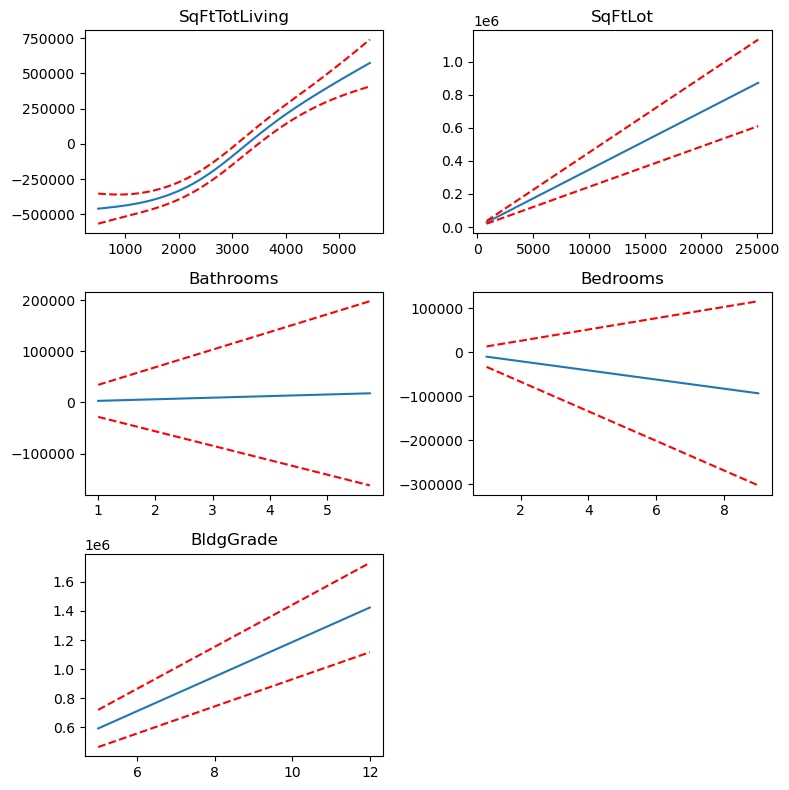

In [2134]:
fig, axes = plt.subplots(figsize=(8, 8), ncols=2, nrows=3)

titles = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms', 'BldgGrade']
for i, title in enumerate(titles):
    ax = axes[i // 2, i % 2]
    XX = gam.generate_X_grid(term=i)
    ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX))
    ax.plot(XX[:, i], gam.partial_dependence(term=i, X=XX, width=.95)[1], c='r', ls='--')
    ax.set_title(titles[i]);
    
axes[2][1].set_visible(False)

plt.tight_layout()
plt.show()

## **Regularization**  

The goal of **regularization** is to reduce overfitting. It is used throughout machine learning.  
Regularization lowers variance and increases bias.


**Multiple regression equation:**  

$$
\hat{y} = \beta_0 + \beta_1 X_1 + \cdots + \beta_p X_p
$$



**Equation for the total residual error, the residual sum of squares (RSS):**  

$$
RSS = \sum_{i=1}^n (y_i - \hat{y}_i)^2 = \sum_{i=1}^n \left(y_i - \beta_0 - \sum_{j=1}^p \beta_j x_{ij}\right)^2
$$

In words, we are subtracting our prediction for each data row from the known true value then summing over all the errors.  
- $n$ is the number of data rows  
- $p$ is the number of features/predictors

(Equation 3.22 in ISLR v2)



**Lasso and Ridge Regression**  

Both add a shrinkage term to RSS, forcing $\beta$ coefficients to be smaller, moving them closer to zero.

- **Lasso:**

  $$
  RSS + \lambda \sum_{j=1}^p |\beta_j|
  $$

- **Ridge:**

  $$
  RSS + \lambda \sum_{j=1}^p \beta_j^2
  $$



**Lasso**  

- Stands for least absolute shrinkage and selection operator  
- Can reduce coefficients to zero, thus eliminating them  
- Uses the $\ell_1$ (L1) penalty: $\|\beta\|_1$


**Related Lasso Methods**  

- **LassoCV** - Cross Validated Lasso  
- **LassoLars** - Lasso model fit with Least Angle Regression  
- **LassoLarsCV** - Cross Validated LassoLars


## **Cross Validation**

In [2135]:
from sklearn.linear_model import Lasso, LassoLars, LassoCV, LassoLarsCV
from sklearn.linear_model import Ridge, RidgeCV

from sklearn.preprocessing import StandardScaler
subset = ['AdjSalePrice', 'SqFtTotLiving', 'SqFtLot', 'Bathrooms', 
          'Bedrooms', 'BldgGrade']

print(house[subset].head())

   AdjSalePrice  SqFtTotLiving  SqFtLot  Bathrooms  Bedrooms  BldgGrade
1      300805.0           2400     9373       3.00         6          7
2     1076162.0           3764    20156       3.75         4         10
3      761805.0           2060    26036       1.75         4          8
4      442065.0           3200     8618       3.75         5          7
5      297065.0           1720     8620       1.75         4          7


In [2136]:
predictors = ['SqFtTotLiving', 'SqFtLot', 'Bathrooms', 'Bedrooms',
              'BldgGrade', 'PropertyType', 'NbrLivingUnits',
              'SqFtFinBasement', 'YrBuilt', 'YrRenovated', 
              'NewConstruction']
outcome = 'AdjSalePrice'

X = pd.get_dummies(house[predictors], drop_first=True)
X['NewConstruction'] = [1 if nc else 0 for nc in X['NewConstruction']]
columns = X.columns
# X = StandardScaler().fit_transform(X * 1.0)
y = house[outcome]

house_lm = LinearRegression()
print(house_lm.fit(X, y)) 


LinearRegression()


In [ ]:
house_lasso = Lasso(alpha=10)
print(house_lasso.fit(X, y)) # → OLS + L1 penalty of strength 10 (coordinate-descent solver).

Lasso(alpha=10)


## **Larger alpha (λ) reduces coefficients**  

Try the two different combinations.

In [2138]:
Method = LassoLars
MethodCV = LassoLarsCV

# Method = Lasso
# MethodCV = LassoCV

Note, you'll have to rerun the entire notebook after the switch.

In [2139]:
alpha_values = []
results = []
for alpha in [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000, 1_000_000, 10_000_000]:
    model = Method(alpha=alpha)
    model.fit(X, y)
    alpha_values.append(alpha)
    results.append(model.coef_)
modelCV = MethodCV(cv=5) # 5 Cross-Validation folds
modelCV.fit(X, y)

LassoLarsCV(cv=5)

## **Regularization**  

The goal of **regularization** is to reduce overfitting. It is used throughout machine learning.  
Regularization lowers variance and increases bias.


**Multiple regression equation:**  

$$
\hat{y} = \beta_0 + \beta_1 X_1 + \cdots + \beta_p X_p
$$



**Equation for the total residual error, the residual sum of squares (RSS):**  

$$
RSS = \sum_{i=1}^n (y_i - \hat{y}_i)^2 = \sum_{i=1}^n \left(y_i - \beta_0 - \sum_{j=1}^p \beta_j x_{ij}\right)^2
$$

In words, we are subtracting our prediction for each data row from the known true value then summing over all the errors.  
- $n$ is the number of data rows  
- $p$ is the number of features/predictors

(Equation 3.22 in ISLR v2)



**Lasso and Ridge Regression**  

Both add a shrinkage term to RSS, forcing $\beta$ coefficients to be smaller, moving them closer to zero.

- **Lasso:**

  $$
  RSS + \lambda \sum_{j=1}^p |\beta_j|
  $$

- **Ridge:**

  $$
  RSS + \lambda \sum_{j=1}^p \beta_j^2
  $$



**Lasso**  

- Stands for least absolute shrinkage and selection operator  
- Can reduce coefficients to zero, thus eliminating them  
- Uses the $\ell_1$ (L1) penalty: $\|\beta\|_1$


**Related Lasso Methods**  

- **LassoCV** - Cross Validated Lasso  
- **LassoLars** - Lasso model fit with Least Angle Regression  
- **LassoLarsCV** - Cross Validated LassoLars


## **Cross Validation**

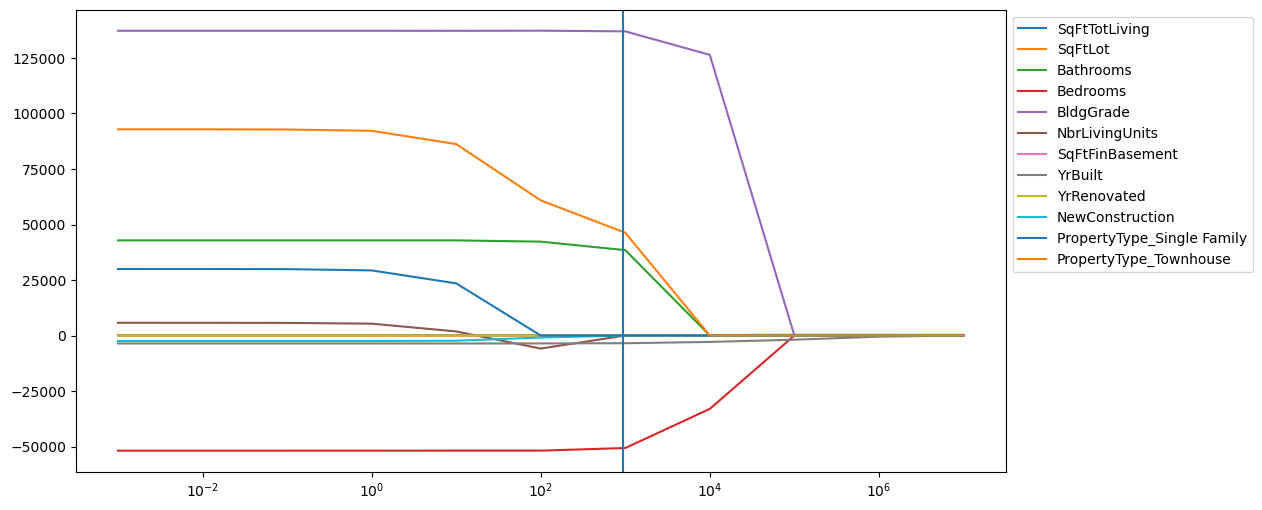

In [2140]:
# plt.figure(figsize=(12,5))
ax = pd.DataFrame(results, index=alpha_values, columns=columns).plot(logx=True, legend=True, figsize=(12, 6))
# plt.legend(loc="upper right")
plt.legend(bbox_to_anchor=(1.0,1.0))

ax.axvline(modelCV.alpha_)
plt.show()

**Examine the coefficients**  

SqFtTotLiving and YrRenovated are largest  

Notice how many coefficients went to zero

In [2141]:
pd.DataFrame({
    'name': columns,
    'coef': modelCV.coef_, 
})

,name,coef
0,SqFtTotLiving,198.520924
1,SqFtLot,0.070347
2,Bathrooms,38733.521693
3,Bedrooms,-50774.560430
4,BldgGrade,137034.833856
5,NbrLivingUnits,0.000000
6,SqFtFinBasement,8.872375
7,YrBuilt,-3474.653950
8,YrRenovated,-0.977854
9,NewConstruction,0.000000


### Ridge Regression

$$
\text{RSS} + \lambda \sum_{j=1}^p \beta_j^2
$$

- Trying to minimize this equation.
- $\lambda$ is the tuning parameter. Forces coefficients to be smaller—closer to zero, but never exactly zero.
- Uses **$\ell_2$ (L2) penalty:** $\Vert \beta \Vert_2$

Coefficients can approach, but never equal, zero—so coefficients are never fully eliminated.


In [2143]:
# sklearn example: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.Ridge.html

from sklearn.linear_model import Ridge
import numpy as np
n_samples, n_features = 10, 5
rng = np.random.RandomState(0)
y = rng.randn(n_samples)
X = rng.randn(n_samples, n_features)
clf = Ridge(alpha=1.0)
clf.fit(X, y)

Ridge()

In [2144]:
from sklearn.linear_model import Ridge
from sklearn.linear_model import RidgeCV

Method = Ridge
MethodCV = RidgeCV

alpha_values = []
results = []
for alpha in [0.001, 0.01, 0.1, 1, 10, 100, 1000, 10000, 100000, 1000000, 10000000]:
    model = Method(alpha=alpha)
    model.fit(X, y)
    alpha_values.append(alpha)
    results.append(model.coef_)
modelCV = MethodCV(cv=5)
modelCV.fit(X, y)

ax = pd.DataFrame(results, index=alpha_values, columns=columns).plot(logx=True, legend=False)
ax.axvline(modelCV.alpha_)
plt.show()

ValueError: 12 columns passed, passed data had 5 columns